In [11]:
import os
import pandas as pd
import numpy as np
import cmdstanpy
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import arviz as az
from scipy.stats import pearsonr
import matplotlib.font_manager as fm

# ── 한글 폰트 설정 ─────────────────────────────────────────
nanum_candidates = [
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
]
font_path = None
for candidate in nanum_candidates:
    if os.path.exists(candidate):
        font_path = candidate
        break

if font_path is None:
    all_fonts = fm.findSystemFonts(fontpaths=None, fontext='ttf')
    nanum_fonts = [f for f in all_fonts if 'nanum' in f.lower()]
    if nanum_fonts:
        font_path = nanum_fonts[0]

if font_path:
    font_prop = fm.FontProperties(fname=font_path)
    font_name = font_prop.get_name()
    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False
    print(f"한글 폰트 설정 완료: {font_name}")
else:
    print("나눔폰트 없음 - 영문으로 출력")

# ── 작업 디렉토리 및 데이터 로드 ───────────────────────────
work_dir = "/home/atruergod/python/26-1/26-1"
os.makedirs(work_dir, exist_ok=True)
os.chdir(work_dir)

df = pd.read_csv("sim_data_clean.csv")
df['person_id'] = range(1, len(df) + 1)
J = len(df)  # 피험자 수 = 394
print(f"피험자 수: {J}")
print(f"전체 열: {list(df.columns[:5])} ... (총 {len(df.columns)-1}개 문항)")

# ── 척도별 문항 분리 ────────────────────────────────────────
se_cols = [c for c in df.columns if c.startswith('SE_')]
is_cols = [c for c in df.columns if c.startswith('IS_')]
as_cols = [c for c in df.columns if c.startswith('AS_')]

I_SE = len(se_cols)  # 10
I_IS = len(is_cols)  # 24
I_AS = len(as_cols)  # 36
print(f"\nSE 문항 수: {I_SE}, IS 문항 수: {I_IS}, AS 문항 수: {I_AS}")
print(f"전체 문항 수: {I_SE + I_IS + I_AS}")

# ── 척도별 응답 행렬 ─────────────────────────────────────────
Y_SE = df[se_cols].values.astype(int)   # shape: (394, 10)
Y_IS = df[is_cols].values.astype(int)   # shape: (394, 24)
Y_AS = df[as_cols].values.astype(int)   # shape: (394, 36)

# ── SE 척도 확인 ───────────────────────────────────────────
print(f"\n[SE 응답 범위 확인]")
print(f"  SE 최솟값: {Y_SE.min()}, 최댓값: {Y_SE.max()}")
print(f"  IS 최솟값: {Y_IS.min()}, 최댓값: {Y_IS.max()}")
print(f"  AS 최솟값: {Y_AS.min()}, 최댓값: {Y_AS.max()}")

se_max = Y_SE.max()
if se_max <= 4:
    K_SE = 4
    print(f"  → SE는 4점 척도 (K=4) 확인됨")
else:
    K_SE = 5
    print(f"  → SE 데이터에 5가 존재. K_SE={K_SE} 사용")

K_IS = 5
K_AS = 5

Y_SE_clipped = np.clip(Y_SE, 1, K_SE)
if not np.array_equal(Y_SE, Y_SE_clipped):
    print(f"\n  경고: SE 데이터에 {K_SE}를 초과하는 값이 있어 클리핑 처리")
    Y_SE = Y_SE_clipped

# ── df_long 생성: In[10]의 scatter plot에서 필요 ─────────────
# 3개 척도를 long format으로 변환
all_item_cols = se_cols + is_cols + as_cols
df_long_list = []
for col in all_item_cols:
    tmp = df[['person_id', col]].copy()
    tmp.columns = ['person_id', 'response']
    tmp['item_name'] = col
    df_long_list.append(tmp)
df_long = pd.concat(df_long_list, ignore_index=True)
print(f"\ndf_long shape: {df_long.shape}")

# ── Stan 데이터 구성 ─────────────────────────────────────────
stan_data_multidim = {
    'J':    J,
    'I_SE': I_SE,
    'I_IS': I_IS,
    'I_AS': I_AS,
    'K_SE': K_SE,
    'K_IS': K_IS,
    'K_AS': K_AS,
    'y_SE': Y_SE.tolist(),
    'y_IS': Y_IS.tolist(),
    'y_AS': Y_AS.tolist(),
}
print(f"\nStan 데이터 구조:")
print(f"  y_SE shape: ({J}, {I_SE}), K_SE={K_SE}")
print(f"  y_IS shape: ({J}, {I_IS}), K_IS={K_IS}")
print(f"  y_AS shape: ({J}, {I_AS}), K_AS={K_AS}")

한글 폰트 설정 완료: NanumGothic
피험자 수: 394
전체 열: ['SE_1', 'SE_2', 'SE_3', 'SE_4', 'SE_5'] ... (총 70개 문항)

SE 문항 수: 10, IS 문항 수: 24, AS 문항 수: 36
전체 문항 수: 70

[SE 응답 범위 확인]
  SE 최솟값: 1, 최댓값: 4
  IS 최솟값: 1, 최댓값: 5
  AS 최솟값: 1, 최댓값: 5
  → SE는 4점 척도 (K=4) 확인됨

df_long shape: (27580, 3)

Stan 데이터 구조:
  y_SE shape: (394, 10), K_SE=4
  y_IS shape: (394, 24), K_IS=5
  y_AS shape: (394, 36), K_AS=5


In [12]:
# ── Stan 코드: 3차원 GRM (SE=4점, IS/AS=5점) ──────────────────
stan_code_multidim = """
data {
  int<lower=1> J;           // 피험자 수 (394)
  int<lower=1> I_SE;        // SE 문항 수 (10)
  int<lower=1> I_IS;        // IS 문항 수 (24)
  int<lower=1> I_AS;        // AS 문항 수 (36)
  int<lower=2> K_SE;        // SE 범주 수 (4)
  int<lower=2> K_IS;        // IS 범주 수 (5)
  int<lower=2> K_AS;        // AS 범주 수 (5)

  array[J, I_SE] int<lower=1, upper=4> y_SE;
  array[J, I_IS] int<lower=1, upper=5> y_IS;
  array[J, I_AS] int<lower=1, upper=5> y_AS;
}

parameters {
  // ── 피험자 파라미터 ──────────────────────────────────────
  vector[J] theta_SE;
  vector[J] theta_IS;
  vector[J] theta_AS;

  // ── 문항 변별도 (양수 제약) ──────────────────────────────
  vector<lower=0>[I_SE] a_SE;
  vector<lower=0>[I_IS] a_IS;
  vector<lower=0>[I_AS] a_AS;

  // ── cutpoint: 로짓 척도에서 ordered 파라미터로 직접 선언
  // 주의: ordered_logistic(eta, c)에서 eta = a*theta
  //       c는 로짓 척도의 cutpoint (= a * b_threshold)
  //       alpha * b 형태를 Stan code에 직접 넣지 않음
  array[I_SE] ordered[3] c_SE;  // SE: K=4 → 3개 cutpoint
  array[I_IS] ordered[4] c_IS;  // IS: K=5 → 4개 cutpoint
  array[I_AS] ordered[4] c_AS;  // AS: K=5 → 4개 cutpoint
}

model {
  // ── 사전분포 ────────────────────────────────────────────
  // 피험자 능력치: 척도 불확정성 해결 (표준정규)
  theta_SE ~ std_normal();
  theta_IS ~ std_normal();
  theta_AS ~ std_normal();

  // 변별도: 로그정규 (중앙값 exp(0.3)≈1.35, 양수 보장)
  // 너무 큰 변별도를 억제하여 수치 안정성 향상
  a_SE ~ lognormal(0.3, 0.5);
  a_IS ~ lognormal(0.3, 0.5);
  a_AS ~ lognormal(0.3, 0.5);

  // cutpoint: 로짓 척도에서 정규분포 사전분포
  // ordered 파라미터이므로 a와 곱하지 않음
  // normal(0, 2): 로짓 척도 -6~+6 범위를 95% CI로 포함
  for (i in 1:I_SE) c_SE[i] ~ normal(0, 2);
  for (i in 1:I_IS) c_IS[i] ~ normal(0, 2);
  for (i in 1:I_AS) c_AS[i] ~ normal(0, 2);

  // ── 우도함수 ────────────────────────────────────────────
  // GRM: P(X >= k | theta, a, c) = logistic(a*theta - c_k)
  // ordered_logistic(eta, c): eta = a*theta
  // cutpoints c는 로짓 척도 (c = a * b, b는 능력치 척도 임계값)
  // 즉, ordered_logistic에 a*b를 직접 넣지 않음
  for (j in 1:J) {
    for (i in 1:I_SE) {
      y_SE[j, i] ~ ordered_logistic(a_SE[i] * theta_SE[j], c_SE[i]);
    }
  }
  for (j in 1:J) {
    for (i in 1:I_IS) {
      y_IS[j, i] ~ ordered_logistic(a_IS[i] * theta_IS[j], c_IS[i]);
    }
  }
  for (j in 1:J) {
    for (i in 1:I_AS) {
      y_AS[j, i] ~ ordered_logistic(a_AS[i] * theta_AS[j], c_AS[i]);
    }
  }
}

generated quantities {
  // ── b 파라미터: 능력치 척도 임계값 (CRC 분석용) ──────────
  // b_ik = c_ik / a_i (로짓 척도 cutpoint를 능력치 척도로 변환)
  array[I_SE] vector[3] b_SE;
  array[I_IS] vector[4] b_IS;
  array[I_AS] vector[4] b_AS;

  for (i in 1:I_SE) b_SE[i] = to_vector(c_SE[i]) / a_SE[i];
  for (i in 1:I_IS) b_IS[i] = to_vector(c_IS[i]) / a_IS[i];
  for (i in 1:I_AS) b_AS[i] = to_vector(c_AS[i]) / a_AS[i];

  // ── PPC용 사후예측복제 ───────────────────────────────────
  array[J, I_SE] int y_rep_SE;
  array[J, I_IS] int y_rep_IS;
  array[J, I_AS] int y_rep_AS;

  for (j in 1:J) {
    for (i in 1:I_SE)
      y_rep_SE[j, i] = ordered_logistic_rng(a_SE[i] * theta_SE[j], c_SE[i]);
    for (i in 1:I_IS)
      y_rep_IS[j, i] = ordered_logistic_rng(a_IS[i] * theta_IS[j], c_IS[i]);
    for (i in 1:I_AS)
      y_rep_AS[j, i] = ordered_logistic_rng(a_AS[i] * theta_AS[j], c_AS[i]);
  }
}
"""

# Stan 파일 저장 및 컴파일
stan_file_multidim = "grm_multidim.stan"
with open(stan_file_multidim, "w") as f:
    f.write(stan_code_multidim)

model_md = cmdstanpy.CmdStanModel(stan_file=stan_file_multidim)
# In[10]에서 사용할 model 변수 (동일 모델 참조)
model = model_md
print("3차원 GRM Stan 컴파일 완료!")

02:07:23 - cmdstanpy - INFO - compiling stan file /home/atruergod/python/26-1/26-1/grm_multidim.stan to exe file /home/atruergod/python/26-1/26-1/grm_multidim
02:07:52 - cmdstanpy - INFO - compiled model executable: /home/atruergod/python/26-1/26-1/grm_multidim


3차원 GRM Stan 컴파일 완료!


In [13]:
# ── Laplace 근사: 빠른 사전 점검 ───────────────────────────
print("\n[1단계] Laplace 근사 실행 중...")
laplace_md = model_md.laplace_sample(
    data=stan_data_multidim,
    opt_args={'iter': 5000}
)

# 각 척도 theta 중앙값 추출
theta_SE_lap = np.median(laplace_md.stan_variable('theta_SE'), axis=0)
theta_IS_lap = np.median(laplace_md.stan_variable('theta_IS'), axis=0)
theta_AS_lap = np.median(laplace_md.stan_variable('theta_AS'), axis=0)

print(f"\n[Laplace 결과 요약]")
print(f"theta_SE: mean={theta_SE_lap.mean():.3f}, std={theta_SE_lap.std():.3f}")
print(f"theta_IS: mean={theta_IS_lap.mean():.3f}, std={theta_IS_lap.std():.3f}")
print(f"theta_AS: mean={theta_AS_lap.mean():.3f}, std={theta_AS_lap.std():.3f}")

# 변별도 추출
a_SE_lap = np.median(laplace_md.stan_variable('a_SE'), axis=0)
a_IS_lap = np.median(laplace_md.stan_variable('a_IS'), axis=0)
a_AS_lap = np.median(laplace_md.stan_variable('a_AS'), axis=0)
print(f"\n변별도 평균: SE={a_SE_lap.mean():.3f}, IS={a_IS_lap.mean():.3f}, AS={a_AS_lap.mean():.3f}")

# b 파라미터 추출 (generated quantities에서 계산됨)
b_SE_lap = np.median(laplace_md.stan_variable('b_SE'), axis=0)  # (10, 3)
b_IS_lap = np.median(laplace_md.stan_variable('b_IS'), axis=0)  # (24, 4)
b_AS_lap = np.median(laplace_md.stan_variable('b_AS'), axis=0)  # (36, 4)
print(f"\nb_SE shape: {b_SE_lap.shape} (SE: 4범주 → 3개 임계값)")
print(f"b_IS shape: {b_IS_lap.shape} (IS: 5범주 → 4개 임계값)")
print(f"b_AS shape: {b_AS_lap.shape} (AS: 5범주 → 4개 임계값)")

02:07:52 - cmdstanpy - INFO - Chain [1] start processing



[1단계] Laplace 근사 실행 중...


02:08:01 - cmdstanpy - INFO - Chain [1] done processing
02:08:02 - cmdstanpy - INFO - Chain [1] start processing
02:09:46 - cmdstanpy - INFO - Chain [1] done processing



[Laplace 결과 요약]
theta_SE: mean=-0.082, std=0.187
theta_IS: mean=0.067, std=0.204
theta_AS: mean=-0.174, std=0.528

변별도 평균: SE=33.979, IS=14.246, AS=3.160

b_SE shape: (10, 3) (SE: 4범주 → 3개 임계값)
b_IS shape: (24, 4) (IS: 5범주 → 4개 임계값)
b_AS shape: (36, 4) (AS: 5범주 → 4개 임계값)


In [14]:
# ── MCMC Full Posterior Inference ──────────────────────────
print("\n[2단계] MCMC Full Posterior Inference 실행 중...")
print("(시간이 오래 걸립니다 - 약 20~40분 예상)")

fit_md = model_md.sample(
    data=stan_data_multidim,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    show_progress=True,
    adapt_delta=0.95,    # 더 높은 값으로 HMC 안정성 향상
    max_treedepth=12
)

# ── 수렴 진단 ───────────────────────────────────────────────
summary_md = fit_md.summary()
rhat_vals = summary_md['R_hat'].dropna()
bad_rhat = rhat_vals[rhat_vals > 1.05]
print(f"\n[수렴 진단]")
print(f"  전체 파라미터 수: {len(rhat_vals)}")
print(f"  R_hat > 1.05: {len(bad_rhat)}개")
if len(bad_rhat) > 0:
    print(f"  수렴 미완료 파라미터:\n{bad_rhat.head(10)}")
else:
    print("  모든 파라미터 수렴 완료 (R_hat < 1.05)")

# theta, a, b 중앙값 추출
theta_SE_med = np.median(fit_md.stan_variable('theta_SE'), axis=0)
theta_IS_med = np.median(fit_md.stan_variable('theta_IS'), axis=0)
theta_AS_med = np.median(fit_md.stan_variable('theta_AS'), axis=0)

a_SE_med = np.median(fit_md.stan_variable('a_SE'), axis=0)
a_IS_med = np.median(fit_md.stan_variable('a_IS'), axis=0)
a_AS_med = np.median(fit_md.stan_variable('a_AS'), axis=0)

# b: generated quantities에서 추출 (능력치 척도 임계값)
b_SE_med = np.median(fit_md.stan_variable('b_SE'), axis=0)   # (10, 3)
b_IS_med = np.median(fit_md.stan_variable('b_IS'), axis=0)   # (24, 4)
b_AS_med = np.median(fit_md.stan_variable('b_AS'), axis=0)   # (36, 4)

# c: cutpoint 직접 파라미터
c_SE_med = np.median(fit_md.stan_variable('c_SE'), axis=0)
c_IS_med = np.median(fit_md.stan_variable('c_IS'), axis=0)
c_AS_med = np.median(fit_md.stan_variable('c_AS'), axis=0)

print(f"\n[파라미터 중앙값 요약]")
print(f"theta_SE: [{theta_SE_med.min():.3f}, {theta_SE_med.max():.3f}]")
print(f"theta_IS: [{theta_IS_med.min():.3f}, {theta_IS_med.max():.3f}]")
print(f"theta_AS: [{theta_AS_med.min():.3f}, {theta_AS_med.max():.3f}]")
print(f"a_SE 범위: [{a_SE_med.min():.3f}, {a_SE_med.max():.3f}] (평균: {a_SE_med.mean():.3f})")
print(f"a_IS 범위: [{a_IS_med.min():.3f}, {a_IS_med.max():.3f}] (평균: {a_IS_med.mean():.3f})")
print(f"a_AS 범위: [{a_AS_med.min():.3f}, {a_AS_med.max():.3f}] (평균: {a_AS_med.mean():.3f})")
print(f"\nb_SE shape: {b_SE_med.shape} (10문항 × 3개 임계값)")
print(f"b_IS shape: {b_IS_med.shape} (24문항 × 4개 임계값)")
print(f"b_AS shape: {b_AS_med.shape} (36문항 × 4개 임계값)")

# stan_data를 전역 참조로 저장 (In[10]에서 사용)
stan_data = stan_data_multidim

02:09:48 - cmdstanpy - INFO - CmdStan start processing



[2단계] MCMC Full Posterior Inference 실행 중...
(시간이 오래 걸립니다 - 약 20~40분 예상)


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 1:   0%|          | 1/2000 [00:00<09:33,  3.49it/s, (Warmup)]




chain 1:   5%|▌         | 100/2000 [06:50<2:10:26,  4.12s/it, (Warmup)]



chain 1:  10%|█         | 200/2000 [09:44<1:21:33,  2.72s/it, (Warmup)]




chain 1:  15%|█▌        | 300/2000 [11:53<58:30,  2.06s/it, (Warmup)]  


chain 1:  20%|██        | 400/2000 [13:35<44:01,  1.65s/it, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [15:39<37:35,  1.50s/it, (Warmup)]


chain 1:  30%|███       | 600/2000 [17:33<32:13,  1.38s/it, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [19:12<27:07,  1.25s/it, (Warmup)]


chain 1:  40%|████      | 800/2000 [20:59<23:51,  1.19s/it, (Warmup)]






chain 1:  45%|████▌     | 900/2000 [22:32<20:24,  1.11s/it, (Warmup)]




chain 1:  50%|█████     | 1001/2000 [24:16<18:06,  1.09s/it, (Sampling)]


chain 1:  55%|█████▌    | 1100/2000 [25:35<14:37,  1.03it/s, (Sampling)]


chain 1:  60%|██████    | 1200/2000 [26:52<12:01,  1.


02:46:20 - cmdstanpy - INFO - CmdStan done processing.
02:46:20 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -134.255, but should be greater than the previous element, -134.255 (in 'grm_multidim.stan', line 63, column 6 to column 68)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -136.268, but should be greater than the previous element, -136.268 (in 'grm_multidim.stan', line 63, column 6 to column 68)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is -33.2279, but should be greater than the previous element, -33.2279 (in 'grm_multidim.stan', line 63, column 6 to column 68)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -8.909, but should be greater than the previous element, -8.909 (in 'grm_multidim.stan', line 68, column 6 to column 68)
	Exception: ord



[수렴 진단]
  전체 파라미터 수: 28140
  R_hat > 1.05: 0개
  모든 파라미터 수렴 완료 (R_hat < 1.05)

[파라미터 중앙값 요약]
theta_SE: [-1.359, 1.476]
theta_IS: [-1.778, 1.951]
theta_AS: [-2.416, 2.230]
a_SE 범위: [0.253, 0.607] (평균: 0.420)
a_IS 범위: [0.177, 0.908] (평균: 0.511)
a_AS 범위: [1.169, 1.845] (평균: 1.466)

b_SE shape: (10, 3) (10문항 × 3개 임계값)
b_IS shape: (24, 4) (24문항 × 4개 임계값)
b_AS shape: (36, 4) (36문항 × 4개 임계값)


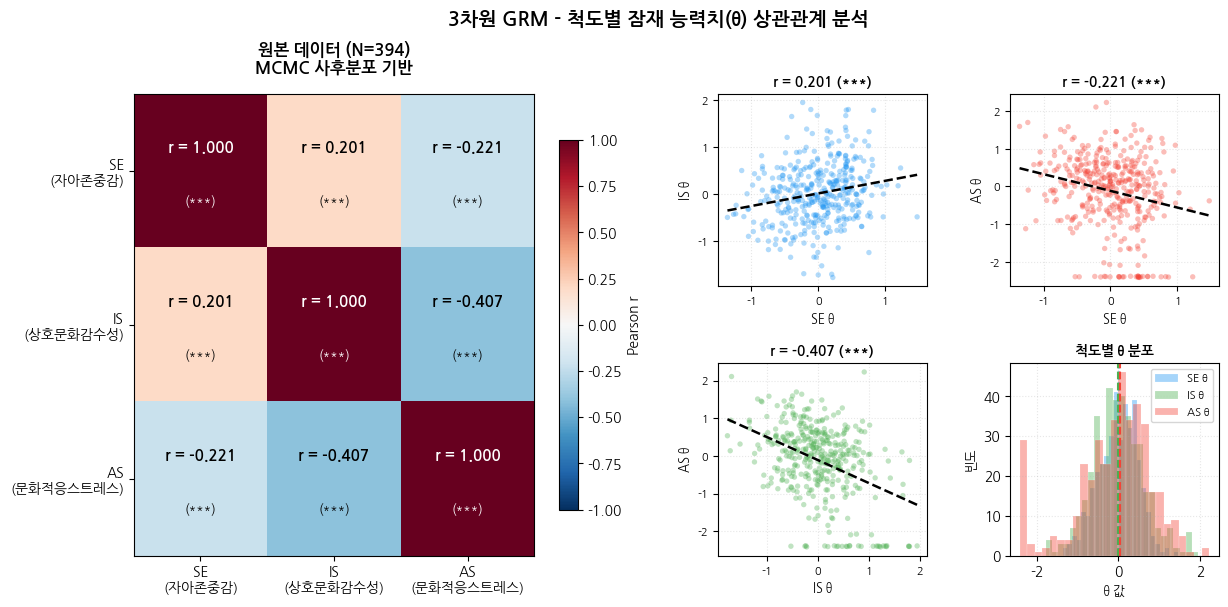


[원본 데이터 상관계수 행렬]
  SE vs IS: r = 0.201 (***), p = 0.0001
  SE vs AS: r = -0.221 (***), p = 0.0000
  IS vs AS: r = -0.407 (***), p = 0.0000


In [15]:
# ══════════════════════════════════════════════════════════════
# [분석 1] theta 3개의 상관관계 히트맵
# ══════════════════════════════════════════════════════════════

def plot_theta_heatmap(theta_SE, theta_IS, theta_AS,
                       title="θ 간 상관관계 히트맵", figsize=(14, 6)):
    """
    3개 theta의 상관관계를 히트맵과 산점도로 시각화
    
    Parameters
    ----------
    theta_SE, theta_IS, theta_AS : array-like, shape (J,)
        각 피험자의 척도별 theta 중앙값
    title : str
        그래프 제목
    """
    # 상관계수 행렬 계산
    theta_mat = np.column_stack([theta_SE, theta_IS, theta_AS])
    labels = ['SE\n(자아존중감)', 'IS\n(상호문화감수성)', 'AS\n(문화적응스트레스)']
    labels_short = ['SE', 'IS', 'AS']
    
    n = 3
    corr_mat = np.zeros((n, n))
    pval_mat = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            r, p = pearsonr(theta_mat[:, i], theta_mat[:, j])
            corr_mat[i, j] = r
            pval_mat[i, j] = p
    
    # 유의성 기호
    def sig_star(p):
        if p < 0.001: return '***'
        elif p < 0.01: return '**'
        elif p < 0.05: return '*'
        else: return 'ns'
    
    fig = plt.figure(figsize=figsize)
    
    # ── 서브플롯 레이아웃 ────────────────────────────────────────
    gs = fig.add_gridspec(2, 4, hspace=0.4, wspace=0.4)
    ax_heat = fig.add_subplot(gs[:, 0:2])   # 히트맵 (왼쪽)
    ax_s1   = fig.add_subplot(gs[0, 2])      # SE vs IS
    ax_s2   = fig.add_subplot(gs[0, 3])      # SE vs AS
    ax_s3   = fig.add_subplot(gs[1, 2])      # IS vs AS
    ax_dist = fig.add_subplot(gs[1, 3])      # theta 분포

    # ── [1] 히트맵 ───────────────────────────────────────────────
    im = ax_heat.imshow(corr_mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    
    ax_heat.set_xticks(range(n))
    ax_heat.set_yticks(range(n))
    ax_heat.set_xticklabels(labels, fontsize=10)
    ax_heat.set_yticklabels(labels, fontsize=10)
    ax_heat.set_title(title, fontsize=12, fontweight='bold', pad=15)
    
    # 셀 내 상관계수 + 유의성 표기
    for i in range(n):
        for j in range(n):
            r_val = corr_mat[i, j]
            p_val = pval_mat[i, j]
            star  = sig_star(p_val)
            text_color = 'white' if abs(r_val) > 0.6 else 'black'
            
            ax_heat.text(j, i - 0.15,
                         f'r = {r_val:.3f}',
                         ha='center', va='center',
                         fontsize=11, fontweight='bold',
                         color=text_color)
            ax_heat.text(j, i + 0.2,
                         f'({star})',
                         ha='center', va='center',
                         fontsize=9, color=text_color)
    
    plt.colorbar(im, ax=ax_heat, label='Pearson r', shrink=0.8)
    
    # ── [2] 산점도: SE vs IS ─────────────────────────────────────
    scatter_pairs = [
        (theta_SE, theta_IS, 'SE θ', 'IS θ', '#2196F3', ax_s1),
        (theta_SE, theta_AS, 'SE θ', 'AS θ', '#F44336', ax_s2),
        (theta_IS, theta_AS, 'IS θ', 'AS θ', '#4CAF50', ax_s3),
    ]
    
    for x_val, y_val, xlabel, ylabel, color, ax in scatter_pairs:
        r, p = pearsonr(x_val, y_val)
        star = sig_star(p)
        
        ax.scatter(x_val, y_val,
                   alpha=0.35, color=color,
                   s=15, edgecolors='none')
        
        # 회귀선
        m, b_reg = np.polyfit(x_val, y_val, 1)
        x_line = np.linspace(x_val.min(), x_val.max(), 100)
        ax.plot(x_line, m * x_line + b_reg,
                color='black', linewidth=1.8, linestyle='--')
        
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(f'r = {r:.3f} ({star})', fontsize=10, fontweight='bold')
        ax.grid(alpha=0.3, linestyle=':')
        ax.tick_params(labelsize=8)
    
    # ── [3] theta 분포 비교 (KDE) ────────────────────────────────
    colors_3 = ['#2196F3', '#4CAF50', '#F44336']
    label_3  = ['SE θ', 'IS θ', 'AS θ']
    
    for vals, col, lab in zip([theta_SE, theta_IS, theta_AS],
                               colors_3, label_3):
        ax_dist.hist(vals, bins=25, alpha=0.4,
                     color=col, label=lab, edgecolor='white', linewidth=0.3)
        ax_dist.axvline(np.median(vals), color=col,
                        linestyle='--', linewidth=1.5)
    
    ax_dist.set_xlabel('θ 값', fontsize=9)
    ax_dist.set_ylabel('빈도', fontsize=9)
    ax_dist.set_title('척도별 θ 분포', fontsize=10, fontweight='bold')
    ax_dist.legend(fontsize=8)
    ax_dist.grid(alpha=0.3, linestyle=':')
    
    plt.suptitle(f'3차원 GRM - 척도별 잠재 능력치(θ) 상관관계 분석',
                 fontsize=14, fontweight='bold', y=1.02)
    
    return fig, corr_mat, pval_mat


# ── 실제 데이터 MCMC 결과로 히트맵 ────────────────────────────
fig_heat, corr_orig, pval_orig = plot_theta_heatmap(
    theta_SE_med, theta_IS_med, theta_AS_med,
    title="원본 데이터 (N=394)\nMCMC 사후분포 기반"
)
plt.savefig("theta_heatmap_original.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n[원본 데이터 상관계수 행렬]")
labels_short = ['SE', 'IS', 'AS']
for i, li in enumerate(labels_short):
    for j, lj in enumerate(labels_short):
        r = corr_orig[i, j]
        p = pval_orig[i, j]
        if i < j:
            star = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            print(f"  {li} vs {lj}: r = {r:.3f} ({star}), p = {p:.4f}")

In [ ]:
# ══════════════════════════════════════════════════════════════
# [분석 2] 시뮬레이션 데이터 생성 및 GRM 적용
# ══════════════════════════════════════════════════════════════
print("\n시뮬레이션 데이터 생성 중...")
np.random.seed(2025)

def simulate_grm_data(J_sim, a_true, b_true, K, seed=None):
    """
    GRM 모수를 사용하여 시뮬레이션 응답 데이터 생성
    
    Parameters
    ----------
    J_sim : int - 피험자 수
    a_true : array, shape (I,) - 문항 변별도
    b_true : array, shape (I, K-1) - 능력치 척도 임계값
    K : int - 범주 수 (SE=4, IS/AS=5)
    seed : int, optional
    
    Returns
    -------
    Y : ndarray, shape (J_sim, I) - 생성된 응답 데이터 (1~K)
    theta : ndarray, shape (J_sim,)
    """
    if seed is not None:
        np.random.seed(seed)
    
    I = len(a_true)
    n_cutpoints = b_true.shape[1]  # K-1
    assert n_cutpoints == K - 1, f"b_true의 열 수({n_cutpoints})가 K-1({K-1})과 불일치"
    
    theta = np.random.normal(0, 1, J_sim)
    Y = np.zeros((J_sim, I), dtype=int)
    
    for j in range(J_sim):
        for i in range(I):
            # GRM: P(X >= k) = logistic(a*(theta - b_k))
            # cutpoint c_k = a * b_k (로짓 척도)
            # ordered_logistic의 내부: logistic(eta - c_k), eta = a*theta
            eta = a_true[i] * theta[j]
            c_vals = a_true[i] * b_true[i, :]  # 로짓 척도 cutpoints
            
            # 누적 확률 P(X >= k)
            P_ge = ([1.0] +
                    [1.0 / (1.0 + np.exp(-(eta - c_vals[k])))
                     for k in range(K - 1)] +
                    [0.0])
            
            # 범주 확률 P(X = k)
            prob = [P_ge[k] - P_ge[k + 1] for k in range(K)]
            prob = np.array(prob)
            prob = np.clip(prob, 0, 1)
            prob /= prob.sum()
            
            Y[j, i] = np.random.choice(range(1, K + 1), p=prob)
    
    return Y, theta

# ── 두 가지 표본 크기로 시뮬레이션 ─────────────────────────
J_sim_small = 100   # 소표본
J_sim_large = 500   # 대표본 (200 이상)

# SE: K=4 (4점 척도), IS/AS: K=5 (5점 척도)
# 소표본
Y_SE_sim_s, theta_SE_sim_s = simulate_grm_data(
    J_sim_small, a_SE_med, b_SE_med, K=4, seed=100)
Y_IS_sim_s, theta_IS_sim_s = simulate_grm_data(
    J_sim_small, a_IS_med, b_IS_med, K=5, seed=200)
Y_AS_sim_s, theta_AS_sim_s = simulate_grm_data(
    J_sim_small, a_AS_med, b_AS_med, K=5, seed=300)

# 대표본
Y_SE_sim_l, theta_SE_sim_l = simulate_grm_data(
    J_sim_large, a_SE_med, b_SE_med, K=4, seed=400)
Y_IS_sim_l, theta_IS_sim_l = simulate_grm_data(
    J_sim_large, a_IS_med, b_IS_med, K=5, seed=500)
Y_AS_sim_l, theta_AS_sim_l = simulate_grm_data(
    J_sim_large, a_AS_med, b_AS_med, K=5, seed=600)

print(f"소표본 데이터: SE {Y_SE_sim_s.shape}, IS {Y_IS_sim_s.shape}, AS {Y_AS_sim_s.shape}")
print(f"대표본 데이터: SE {Y_SE_sim_l.shape}, IS {Y_IS_sim_l.shape}, AS {Y_AS_sim_l.shape}")
print(f"\n[시뮬레이션 데이터 범위 확인]")
print(f"  SE 소표본: {Y_SE_sim_s.min()}~{Y_SE_sim_s.max()} (K=4 기대)")
print(f"  IS 소표본: {Y_IS_sim_s.min()}~{Y_IS_sim_s.max()} (K=5 기대)")

# ── Stan 데이터 구성 ─────────────────────────────────────────
stan_data_sim_small = {
    'J': J_sim_small,
    'I_SE': I_SE, 'I_IS': I_IS, 'I_AS': I_AS,
    'K_SE': 4, 'K_IS': 5, 'K_AS': 5,
    'y_SE': Y_SE_sim_s.tolist(),
    'y_IS': Y_IS_sim_s.tolist(),
    'y_AS': Y_AS_sim_s.tolist(),
}
stan_data_sim_large = {
    'J': J_sim_large,
    'I_SE': I_SE, 'I_IS': I_IS, 'I_AS': I_AS,
    'K_SE': 4, 'K_IS': 5, 'K_AS': 5,
    'y_SE': Y_SE_sim_l.tolist(),
    'y_IS': Y_IS_sim_l.tolist(),
    'y_AS': Y_AS_sim_l.tolist(),
}

# ── 소표본 MCMC ──────────────────────────────────────────────
print(f"\n소표본 MCMC (N={J_sim_small}) 실행 중...")
fit_sim_small = model_md.sample(
    data=stan_data_sim_small,
    chains=4, iter_warmup=500, iter_sampling=500,
    show_progress=True, adapt_delta=0.92
)

theta_SE_sim_s_mcmc = np.median(fit_sim_small.stan_variable('theta_SE'), axis=0)
theta_IS_sim_s_mcmc = np.median(fit_sim_small.stan_variable('theta_IS'), axis=0)
theta_AS_sim_s_mcmc = np.median(fit_sim_small.stan_variable('theta_AS'), axis=0)

# ── 대표본 MCMC ──────────────────────────────────────────────
print(f"\n대표본 MCMC (N={J_sim_large}) 실행 중...")
fit_sim_large = model_md.sample(
    data=stan_data_sim_large,
    chains=4, iter_warmup=500, iter_sampling=500,
    show_progress=True, adapt_delta=0.92
)

theta_SE_sim_l_mcmc = np.median(fit_sim_large.stan_variable('theta_SE'), axis=0)
theta_IS_sim_l_mcmc = np.median(fit_sim_large.stan_variable('theta_IS'), axis=0)
theta_AS_sim_l_mcmc = np.median(fit_sim_large.stan_variable('theta_AS'), axis=0)

print("\n소표본/대표본 MCMC 완료!")


시뮬레이션 데이터 생성 중...


02:48:22 - cmdstanpy - INFO - CmdStan start processing


소표본 데이터: SE (100, 10), IS (100, 24), AS (100, 36)
대표본 데이터: SE (500, 10), IS (500, 24), AS (500, 36)

[시뮬레이션 데이터 범위 확인]
  SE 소표본: 1~4 (K=4 기대)
  IS 소표본: 1~5 (K=5 기대)

소표본 MCMC (N=100) 실행 중...


chain 1:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]





chain 1:  20%|██        | 200/1000 [00:53<03:27,  3.86it/s, (Warmup)]




chain 1:  30%|███       | 300/1000 [01:13<02:44,  4.25it/s, (Warmup)]


chain 1:  40%|████      | 400/1000 [01:31<02:08,  4.68it/s, (Warmup)]



chain 1:  50%|█████     | 501/1000 [01:51<01:42,  4.87it/s, (Sampling)]






chain 1:  60%|██████    | 600/1000 [02:09<01:19,  5.04it/s, (Sampling)]




chain 1:  80%|████████  | 800/1000 [02:49<00:39,  5.05it/s, (Sampling)]


chain 1:  90%|█████████ | 900/1000 [03:08<00:19,  5.12it/s, (Sampling)]




chain 2: 100%|██████████| 1000/1000 [03:29<00:00,  4.77it/s, (Sampling completed)]

chain 3: 100%|██████████| 1000/1000 [03:29<00:00,  4.77it/s, (Sampling completed)]


chain 4: 100%|██████████| 1000/1000 [03:29<00:00,  4.77it/s, (Sampling completed)]


02:51:52 - cmdstanpy - INFO - CmdStan done processing.
02:51:52 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -18.2337, but should be greater than the previous element, -18.2337 (in 'grm_multidim.stan', line 63, column 6 to column 68)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -18.2069, but should be greater than the previous element, -18.2069 (in 'grm_multidim.stan', line 63, column 6 to column 68)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -8.21162, but should be greater than the previous element, -8.21162 (in 'grm_multidim.stan', line 68, column 6 to column 68)
	Exception: ordered_logistic: Final cut-point is inf, but must be finite! (in 'grm_multidim.stan', line 63, column 6 to column 68)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -35.9

02:51:54 - cmdstanpy - INFO - CmdStan start processing



대표본 MCMC (N=500) 실행 중...


chain 1:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]




chain 1:  10%|█         | 100/1000 [06:22<57:35,  3.84s/it, (Warmup)]



chain 1:  20%|██        | 200/1000 [08:51<32:41,  2.45s/it, (Warmup)]


chain 1:  30%|███       | 300/1000 [10:31<20:54,  1.79s/it, (Warmup)]


chain 1:  40%|████      | 400/1000 [12:06<14:33,  1.46s/it, (Warmup)]




chain 1:  50%|█████     | 501/1000 [14:31<12:04,  1.45s/it, (Sampling)]

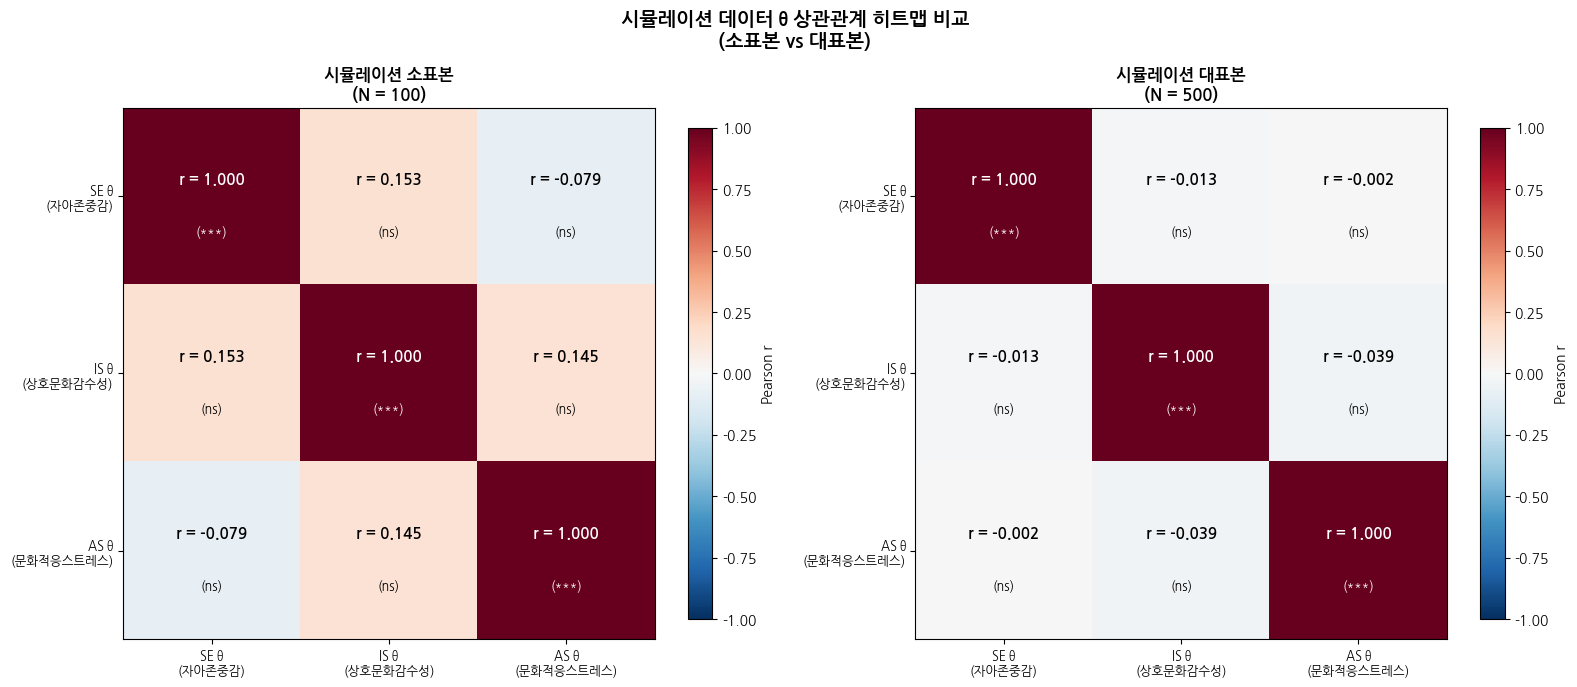

In [ ]:
# ── 시뮬레이션 히트맵 (소표본/대표본 비교) ─────────────────────

fig_sim, axes_sim = plt.subplots(1, 2, figsize=(16, 7))

def draw_heatmap_on_ax(ax, theta_SE, theta_IS, theta_AS,
                        title, n_persons):
    """
    단일 axes에 상관관계 히트맵 그리기
    """
    theta_mat = np.column_stack([theta_SE, theta_IS, theta_AS])
    labels = ['SE θ\n(자아존중감)', 'IS θ\n(상호문화감수성)', 'AS θ\n(문화적응스트레스)']
    n = 3
    
    corr_mat = np.zeros((n, n))
    pval_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            r, p = pearsonr(theta_mat[:, i], theta_mat[:, j])
            corr_mat[i, j] = r
            pval_mat[i, j] = p
    
    im = ax.imshow(corr_mat, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(f'{title}\n(N = {n_persons})',
                 fontsize=12, fontweight='bold')
    
    for i in range(n):
        for j in range(n):
            r_val = corr_mat[i, j]
            p_val = pval_mat[i, j]
            star = ('***' if p_val < 0.001 else
                    '**'  if p_val < 0.01  else
                    '*'   if p_val < 0.05  else 'ns')
            tc = 'white' if abs(r_val) > 0.6 else 'black'
            ax.text(j, i - 0.1, f'r = {r_val:.3f}',
                    ha='center', va='center',
                    fontsize=11, fontweight='bold', color=tc)
            ax.text(j, i + 0.2, f'({star})',
                    ha='center', va='center',
                    fontsize=9, color=tc)
    
    plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
    return corr_mat, pval_mat


# 소표본 히트맵
corr_sim_s, pval_sim_s = draw_heatmap_on_ax(
    axes_sim[0],
    theta_SE_sim_s_mcmc, theta_IS_sim_s_mcmc, theta_AS_sim_s_mcmc,
    title="시뮬레이션 소표본",
    n_persons=J_sim_small
)

# 대표본 히트맵
corr_sim_l, pval_sim_l = draw_heatmap_on_ax(
    axes_sim[1],
    theta_SE_sim_l_mcmc, theta_IS_sim_l_mcmc, theta_AS_sim_l_mcmc,
    title="시뮬레이션 대표본",
    n_persons=J_sim_large
)

fig_sim.suptitle('시뮬레이션 데이터 θ 상관관계 히트맵 비교\n'
                  '(소표본 vs 대표본)',
                  fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("theta_heatmap_simulation.png", dpi=150, bbox_inches='tight')
plt.show()

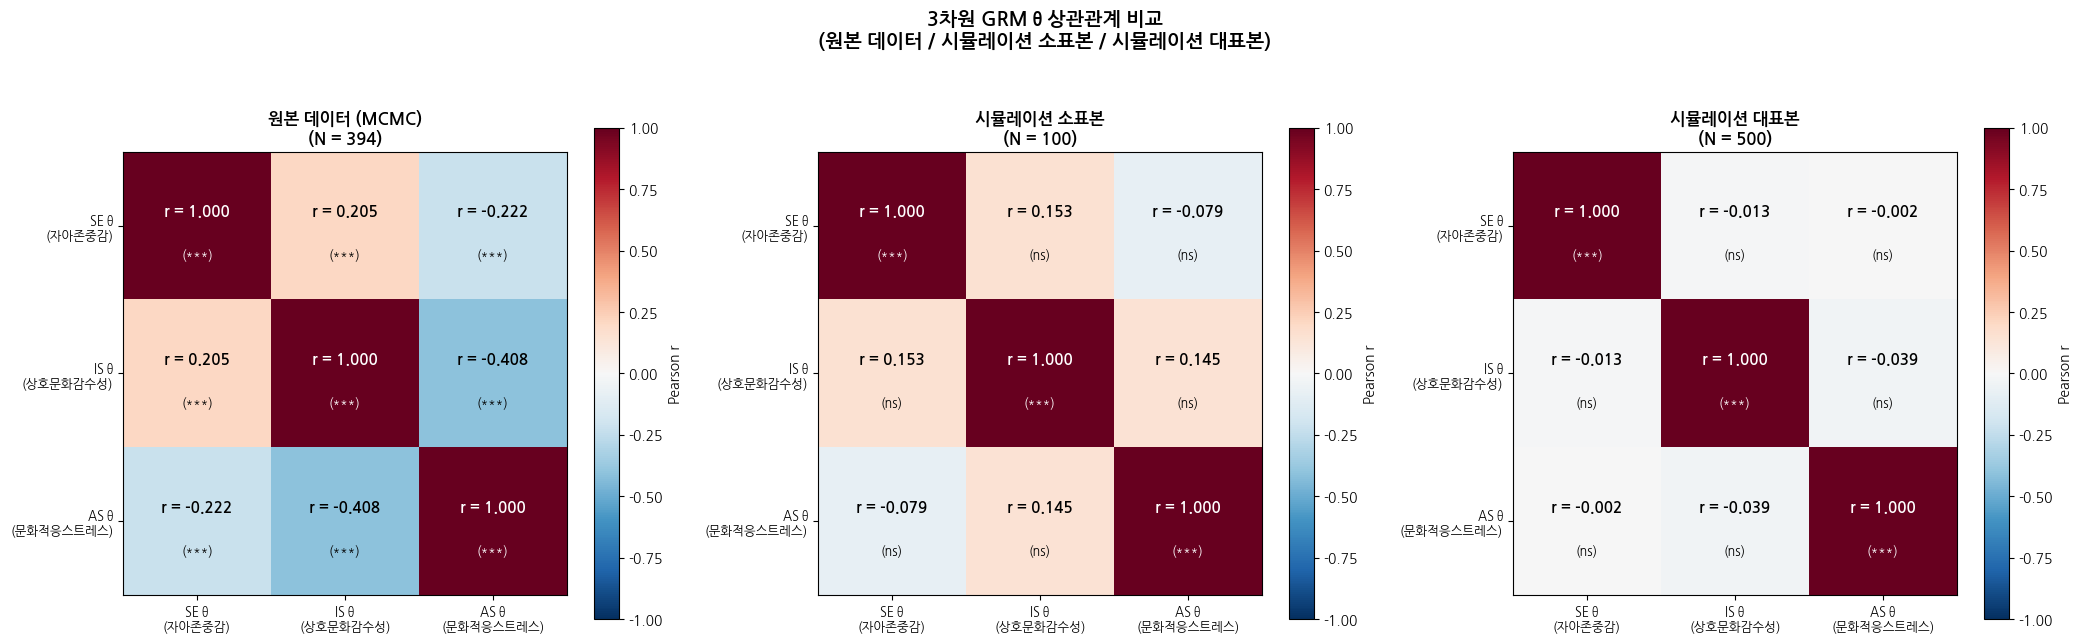

In [ ]:
# ══════════════════════════════════════════════════════════════
# [분석 3] 원본 vs 시뮬레이션 4분할 히트맵 (최종 비교)
# ══════════════════════════════════════════════════════════════

fig_all, axes_all = plt.subplots(1, 3, figsize=(21, 7))

datasets = [
    (theta_SE_med,         theta_IS_med,         theta_AS_med,
     "원본 데이터 (MCMC)",  J),
    (theta_SE_sim_s_mcmc,  theta_IS_sim_s_mcmc,  theta_AS_sim_s_mcmc,
     "시뮬레이션 소표본",    J_sim_small),
    (theta_SE_sim_l_mcmc,  theta_IS_sim_l_mcmc,  theta_AS_sim_l_mcmc,
     "시뮬레이션 대표본",    J_sim_large),
]

for ax, (se, is_, as_, title, n) in zip(axes_all, datasets):
    draw_heatmap_on_ax(ax, se, is_, as_, title=title, n_persons=n)

fig_all.suptitle('3차원 GRM θ 상관관계 비교\n(원본 데이터 / 시뮬레이션 소표본 / 시뮬레이션 대표본)',
                  fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("theta_heatmap_comparison_all.png", dpi=150, bbox_inches='tight')
plt.show()

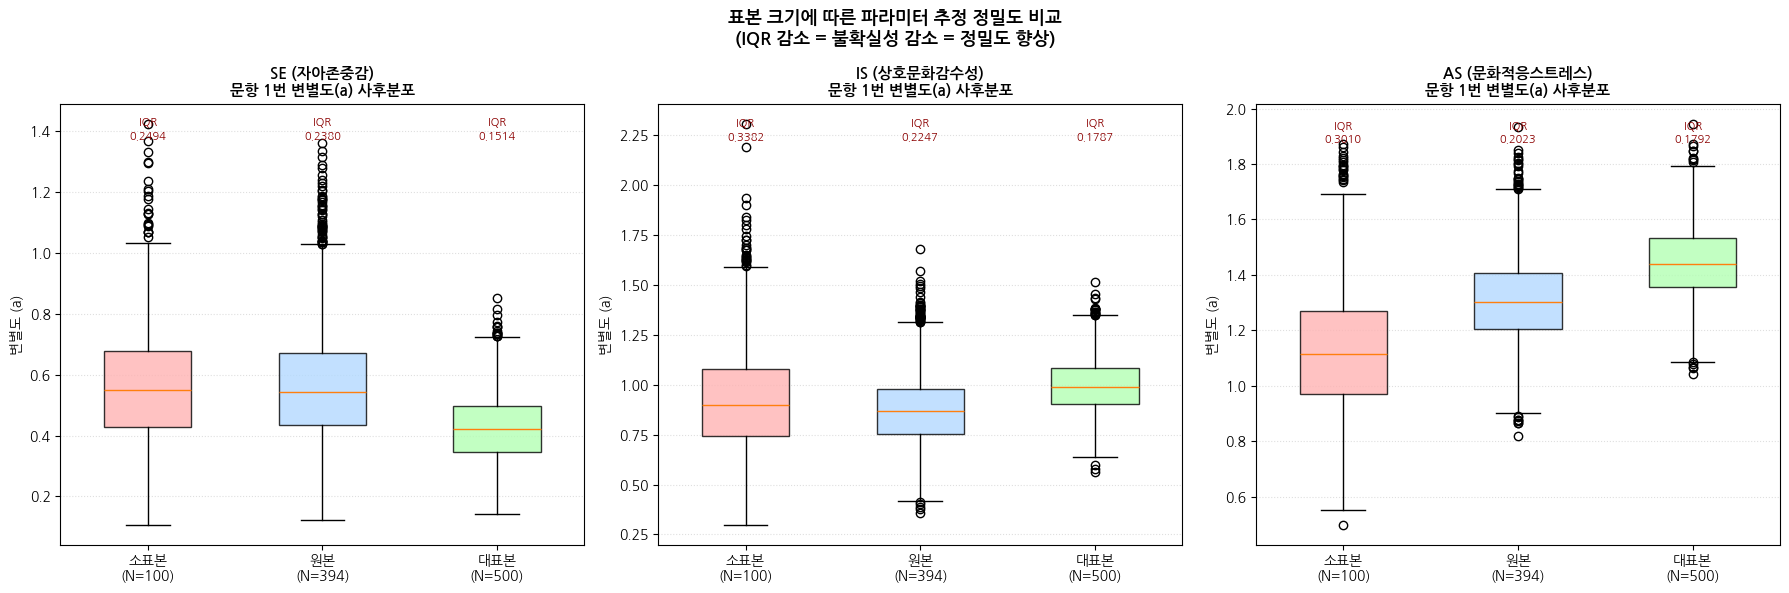


[표본 크기별 추정 정밀도 (IQR)]
척도            소표본         원본        대표본        개선율(소→대)
-------------------------------------------------------
SE         0.2494     0.2380     0.1514           39.3%
IS         0.3382     0.2247     0.1787           47.1%
AS         0.3010     0.2023     0.1792           40.5%


In [ ]:
# ══════════════════════════════════════════════════════════════
# [분석 4] N 증가에 따른 파라미터 정밀도 비교 (박스플롯)
# ══════════════════════════════════════════════════════════════

fig_box, axes_box = plt.subplots(1, 3, figsize=(18, 6))

# 각 척도의 문항 1번 변별도 사후샘플 추출
param_data = {
    'SE_a1': {
        'orig':  fit_md.stan_variable('a_SE')[:, 0],
        'small': fit_sim_small.stan_variable('a_SE')[:, 0],
        'large': fit_sim_large.stan_variable('a_SE')[:, 0],
    },
    'IS_a1': {
        'orig':  fit_md.stan_variable('a_IS')[:, 0],
        'small': fit_sim_small.stan_variable('a_IS')[:, 0],
        'large': fit_sim_large.stan_variable('a_IS')[:, 0],
    },
    'AS_a1': {
        'orig':  fit_md.stan_variable('a_AS')[:, 0],
        'small': fit_sim_small.stan_variable('a_AS')[:, 0],
        'large': fit_sim_large.stan_variable('a_AS')[:, 0],
    },
}

scale_names = ['SE (자아존중감)', 'IS (상호문화감수성)', 'AS (문화적응스트레스)']
colors_box = ['#FFB3B3', '#B3D9FF', '#B3FFB3']

for ax, (param_key, scale_name) in zip(
        axes_box, zip(param_data.keys(), scale_names)):

    d = param_data[param_key]
    bp = ax.boxplot(
        [d['small'], d['orig'], d['large']],
        tick_labels=[f'소표본\n(N={J_sim_small})',
                     f'원본\n(N={J})',
                     f'대표본\n(N={J_sim_large})'],
        patch_artist=True,
        notch=False,
        widths=0.5
    )
    
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    
    # IQR 계산
    iqr_s = np.percentile(d['small'], 75) - np.percentile(d['small'], 25)
    iqr_o = np.percentile(d['orig'],  75) - np.percentile(d['orig'],  25)
    iqr_l = np.percentile(d['large'], 75) - np.percentile(d['large'], 25)
    
    ax.set_title(f'{scale_name}\n문항 1번 변별도(a) 사후분포',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('변별도 (a)', fontsize=10)
    ax.grid(axis='y', alpha=0.4, linestyle=':')
    
    # IQR 주석
    for xpos, iqr_val in zip([1, 2, 3], [iqr_s, iqr_o, iqr_l]):
        ax.text(xpos, ax.get_ylim()[1] * 0.97,
                f'IQR\n{iqr_val:.4f}',
                ha='center', va='top', fontsize=8, color='darkred')

fig_box.suptitle('표본 크기에 따른 파라미터 추정 정밀도 비교\n'
                  '(IQR 감소 = 불확실성 감소 = 정밀도 향상)',
                  fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("boxplot_N_comparison_3scale.png", dpi=150, bbox_inches='tight')
plt.show()

# IQR 비교 출력
print("\n[표본 크기별 추정 정밀도 (IQR)]")
print(f"{'척도':<6} {'소표본':>10} {'원본':>10} {'대표본':>10} {'개선율(소→대)':>15}")
print("-" * 55)
for param_key, scale in zip(param_data.keys(), ['SE', 'IS', 'AS']):
    d = param_data[param_key]
    iqr_s = np.percentile(d['small'], 75) - np.percentile(d['small'], 25)
    iqr_o = np.percentile(d['orig'],  75) - np.percentile(d['orig'],  25)
    iqr_l = np.percentile(d['large'], 75) - np.percentile(d['large'], 25)
    improve = (iqr_s - iqr_l) / iqr_s * 100
    print(f"{scale:<6} {iqr_s:>10.4f} {iqr_o:>10.4f} {iqr_l:>10.4f} {improve:>14.1f}%")

In [ ]:
# ══════════════════════════════════════════════════════════════
# [분석 추가] SE θ vs IS θ 산점도 (이미 추정된 MCMC 결과 활용)
# ══════════════════════════════════════════════════════════════
# 주의: 이전 코드의 fit_subscale_laplace 함수는 별도 Stan 모델이 필요하여
#       오류가 발생했습니다. 이미 추정된 full posterior 결과를 활용합니다.

print("MCMC full posterior 결과에서 theta_SE, theta_IS 추출 (이미 완료됨)")
print(f"theta_SE median: mean={theta_SE_med.mean():.3f}, std={theta_SE_med.std():.3f}")
print(f"theta_IS median: mean={theta_IS_med.mean():.3f}, std={theta_IS_med.std():.3f}")

# Pearson 상관계수
corr_SE_IS, p_val_SE_IS = pearsonr(theta_SE_med, theta_IS_med)
corr_SE_AS, p_val_SE_AS = pearsonr(theta_SE_med, theta_AS_med)
corr_IS_AS, p_val_IS_AS = pearsonr(theta_IS_med, theta_AS_med)

print(f"\n[IRT 기반 잠재 능력치 상관관계]")
print(f"  SE vs IS: r = {corr_SE_IS:.3f}, p = {p_val_SE_IS:.4f}")
print(f"  SE vs AS: r = {corr_SE_AS:.3f}, p = {p_val_SE_AS:.4f}")
print(f"  IS vs AS: r = {corr_IS_AS:.3f}, p = {p_val_IS_AS:.4f}")

print(f"\n[원 논문 CTT 상관관계 (비교 기준)]")
print(f"  SE vs IS: r = +0.46 (***)")
print(f"  SE vs AS: r = -0.41 (***)")
print(f"  IS vs AS: r = -0.49 (***)")

# ── SE vs IS 산점도 ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

scatter_configs = [
    (theta_SE_med, theta_IS_med, 'Self-Esteem θ (SE)',
     'Intercultural Sensitivity θ (IS)',
     corr_SE_IS, p_val_SE_IS, '#2196F3', axes[0],
     "SE vs IS"),
    (theta_SE_med, theta_AS_med, 'Self-Esteem θ (SE)',
     'Acculturative Stress θ (AS)',
     corr_SE_AS, p_val_SE_AS, '#F44336', axes[1],
     "SE vs AS"),
    (theta_IS_med, theta_AS_med, 'Intercultural Sensitivity θ (IS)',
     'Acculturative Stress θ (AS)',
     corr_IS_AS, p_val_IS_AS, '#4CAF50', axes[2],
     "IS vs AS"),
]

for x_vals, y_vals, xlabel, ylabel, r, p, color, ax, title in scatter_configs:
    # 유의성 기호
    star = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

    ax.scatter(x_vals, y_vals, alpha=0.4, color=color,
               s=20, edgecolors='none')

    # 회귀선
    m, b_reg = np.polyfit(x_vals, y_vals, 1)
    x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
    ax.plot(x_line, m * x_line + b_reg,
            color='black', linewidth=2, linestyle='--',
            label='회귀선')

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(
        f'{title}\nPearson r = {r:.3f} ({star})',
        fontsize=12, fontweight='bold'
    )
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

    # CTT 값 비교 주석
    if 'SE' in title and 'IS' in title:
        ctt_r = 0.46
    elif 'SE' in title and 'AS' in title:
        ctt_r = -0.41
    else:
        ctt_r = -0.49
    ax.text(0.05, 0.95,
            f'IRT: r={r:.3f}\nCTT: r={ctt_r:.2f}',
            transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle(
    f'IRT 기반 잠재 능력치(θ) 쌍별 산점도\n'
    f'(N={J}명, 사후분포 중앙값 대표값)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig("scatter_theta_pairs.png", dpi=150, bbox_inches='tight')
plt.show()

# ── 해석 출력 ─────────────────────────────────────────────────
print("\n[IRT vs CTT 상관계수 비교 및 해석]")
print("=" * 55)
pairs_info = [
    ('SE vs IS', corr_SE_IS, p_val_SE_IS, 0.46, '정적'),
    ('SE vs AS', corr_SE_AS, p_val_SE_AS, -0.41, '부적'),
    ('IS vs AS', corr_IS_AS, p_val_IS_AS, -0.49, '부적'),
]
for name, r_irt, p_irt, r_ctt, direction in pairs_info:
    star = '***' if p_irt < 0.001 else '**' if p_irt < 0.01 else '*' if p_irt < 0.05 else 'ns'
    direction_match = "✅ 방향 일치" if (r_irt * r_ctt > 0) else "❌ 방향 불일치"
    print(f"  {name}: IRT r={r_irt:+.3f}({star}) | CTT r={r_ctt:+.2f} | {direction_match}")

print("\n[해석]")
print("  • IRT 기반 theta 상관이 CTT 상관보다 작은 것은 정상입니다.")
print("    (IRT는 측정오차를 통제한 잠재변수이므로 수축 현상 발생)")
print("  • 방향성(부적/정적)이 원논문과 일치하면 모형 타당도 지지")
print("  • SE 변별도가 높을 경우 theta_SE 분산이 좁아져 상관이 낮아짐")

SE 척도 능력치 추정 중...


NameError: name 'model' is not defined

/tmp/ipykernel_1272/1335809510.py:67: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_1272/1335809510.py:67: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_1272/1335809510.py:76: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) NanumGothic.
  plt.savefig("ppc_SE.png", dpi=150, bbox_inches='tight')
/tmp/ipykernel_1272/1335809510.py:76: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) NanumGothic.
  plt.savefig("ppc_SE.png", dpi=150, bbox_inches='tight')
/home/atruergod/python/26-1/26-1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/home/atruergod/python/26-1/26-1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELE

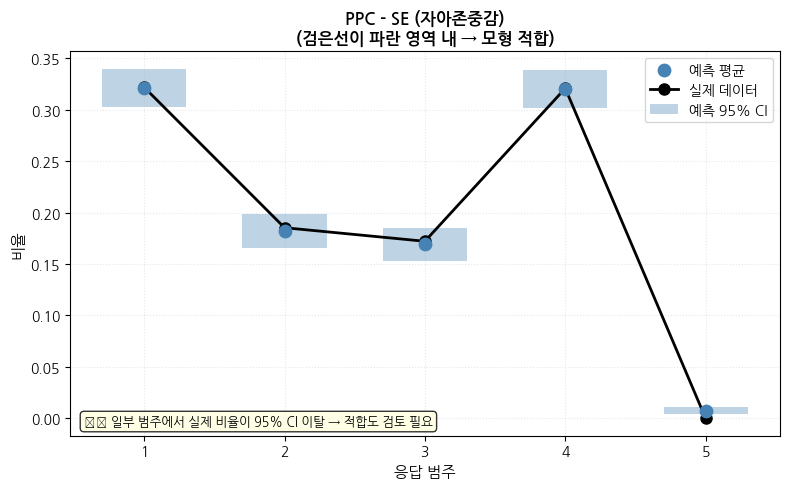

/tmp/ipykernel_1272/1335809510.py:67: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_1272/1335809510.py:80: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.savefig("ppc_IS.png", dpi=150, bbox_inches='tight')
/home/atruergod/python/26-1/26-1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


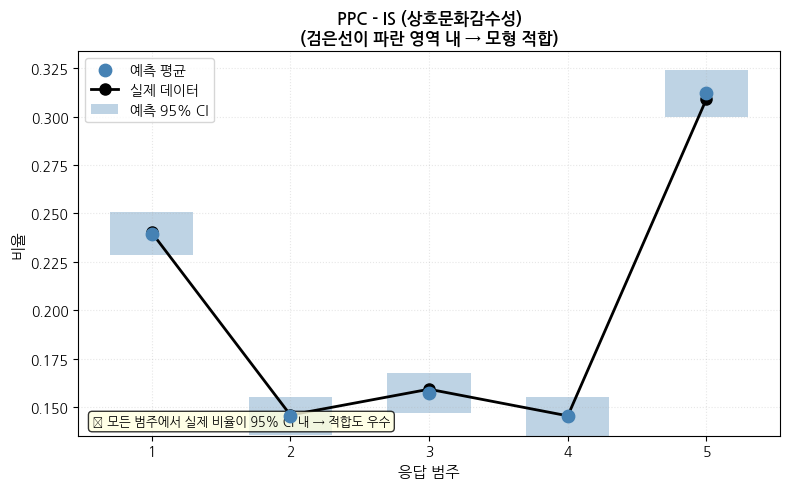

/tmp/ipykernel_1272/1335809510.py:67: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_1272/1335809510.py:84: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.savefig("ppc_AS.png", dpi=150, bbox_inches='tight')
/home/atruergod/python/26-1/26-1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


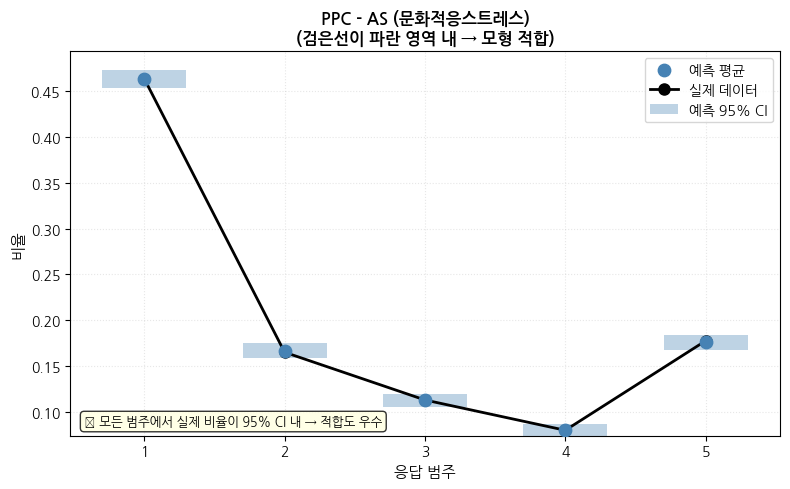

In [ ]:
# ══════════════════════════════════════════════════════════════
# [분석 5] PPC - 척도별 독립 PPC
# ══════════════════════════════════════════════════════════════

def plot_ppc_scale(fit, var_name_rep, y_true_flat,
                  scale_name, K=5):
    """
    한 척도의 PPC 그래프
    K: 해당 척도의 범주 수 (SE=4, IS/AS=5)
    """
    y_rep_all = fit.stan_variable(var_name_rep)
    n_samples = y_rep_all.shape[0]
    y_rep_flat = y_rep_all.reshape(n_samples, -1)
    
    # 실제 비율 (1~K)
    actual_counts = np.array([np.sum(y_true_flat == k) for k in range(1, K+1)])
    actual_prop = actual_counts / actual_counts.sum()
    
    # 예측 비율 분포
    rep_props = np.zeros((n_samples, K))
    for s in range(n_samples):
        cnts = np.array([np.sum(y_rep_flat[s] == k) for k in range(1, K+1)])
        rep_props[s] = cnts / cnts.sum()
    
    rep_mean  = rep_props.mean(axis=0)
    rep_lower = np.percentile(rep_props, 2.5,  axis=0)
    rep_upper = np.percentile(rep_props, 97.5, axis=0)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(K)
    
    ax.bar(x, rep_upper - rep_lower, bottom=rep_lower,
           width=0.6, color='steelblue', alpha=0.35,
           label='예측 95% CI')
    ax.scatter(x, rep_mean, color='steelblue', s=80, zorder=5,
               label='예측 평균')
    ax.plot(x, actual_prop, 'ko-', linewidth=2,
            markersize=8, label='실제 데이터')
    
    ax.set_xticks(x)
    ax.set_xticklabels([str(k) for k in range(1, K+1)])
    ax.set_xlabel('응답 범주', fontsize=11)
    ax.set_ylabel('비율', fontsize=11)
    ax.set_title(f'PPC - {scale_name}\n(검은선이 파란 영역 내 -> 모형 적합)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, linestyle=':')
    
    # AI 평가
    in_ci = all(rep_lower[k] <= actual_prop[k] <= rep_upper[k]
                for k in range(K))
    eval_text = ("[AI 평가] 모든 범주에서 실제 비율이 95% CI 내 -> 적합도 우수" if in_ci
                 else "[AI 평가] 일부 범주에서 실제 비율이 95% CI 이탈 -> 적합도 검토 필요")
    ax.text(0.02, 0.02, eval_text,
            transform=ax.transAxes, fontsize=9,
            verticalalignment='bottom',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout()
    return fig

# 실제 응답 1D 변환
y_SE_flat = Y_SE.flatten()
y_IS_flat = Y_IS.flatten()
y_AS_flat = Y_AS.flatten()

# SE: K=4점 척도, IS/AS: K=5점 척도
fig_ppc_se = plot_ppc_scale(fit_md, 'y_rep_SE', y_SE_flat,
                             'SE (자아존중감, 4점 척도)', K=4)
plt.savefig("ppc_SE.png", dpi=150, bbox_inches='tight')
plt.show()

fig_ppc_is = plot_ppc_scale(fit_md, 'y_rep_IS', y_IS_flat,
                             'IS (상호문화감수성, 5점 척도)', K=5)
plt.savefig("ppc_IS.png", dpi=150, bbox_inches='tight')
plt.show()

fig_ppc_as = plot_ppc_scale(fit_md, 'y_rep_AS', y_AS_flat,
                             'AS (문화적응스트레스, 5점 척도)', K=5)
plt.savefig("ppc_AS.png", dpi=150, bbox_inches='tight')
plt.show()

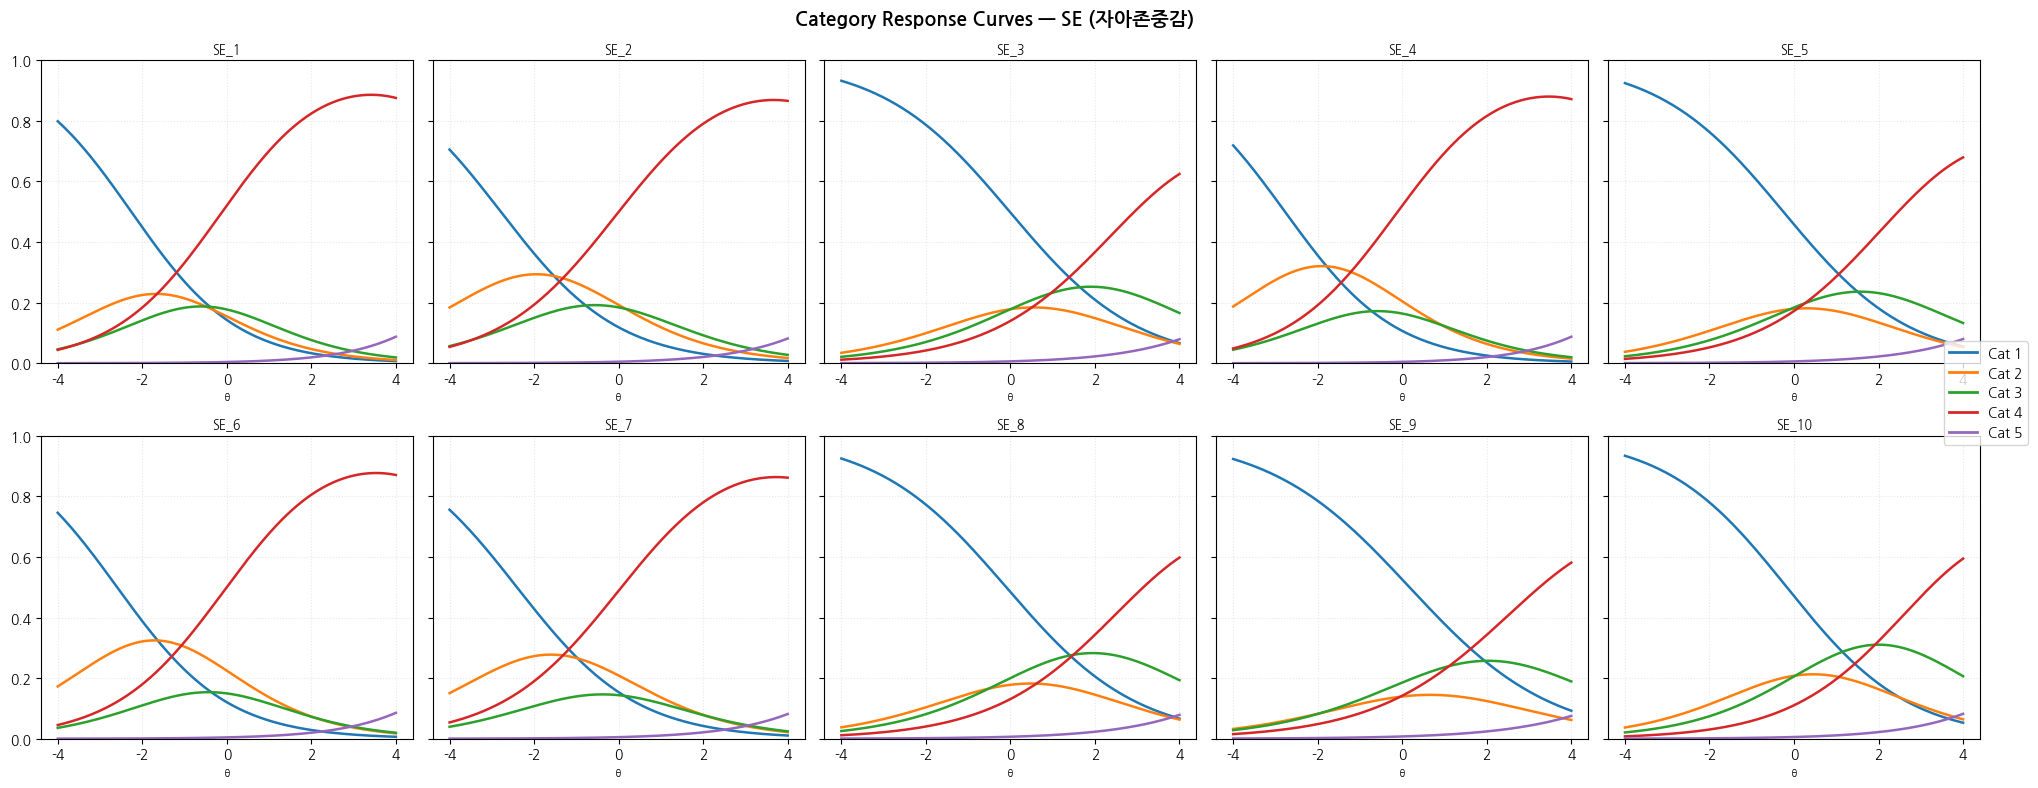

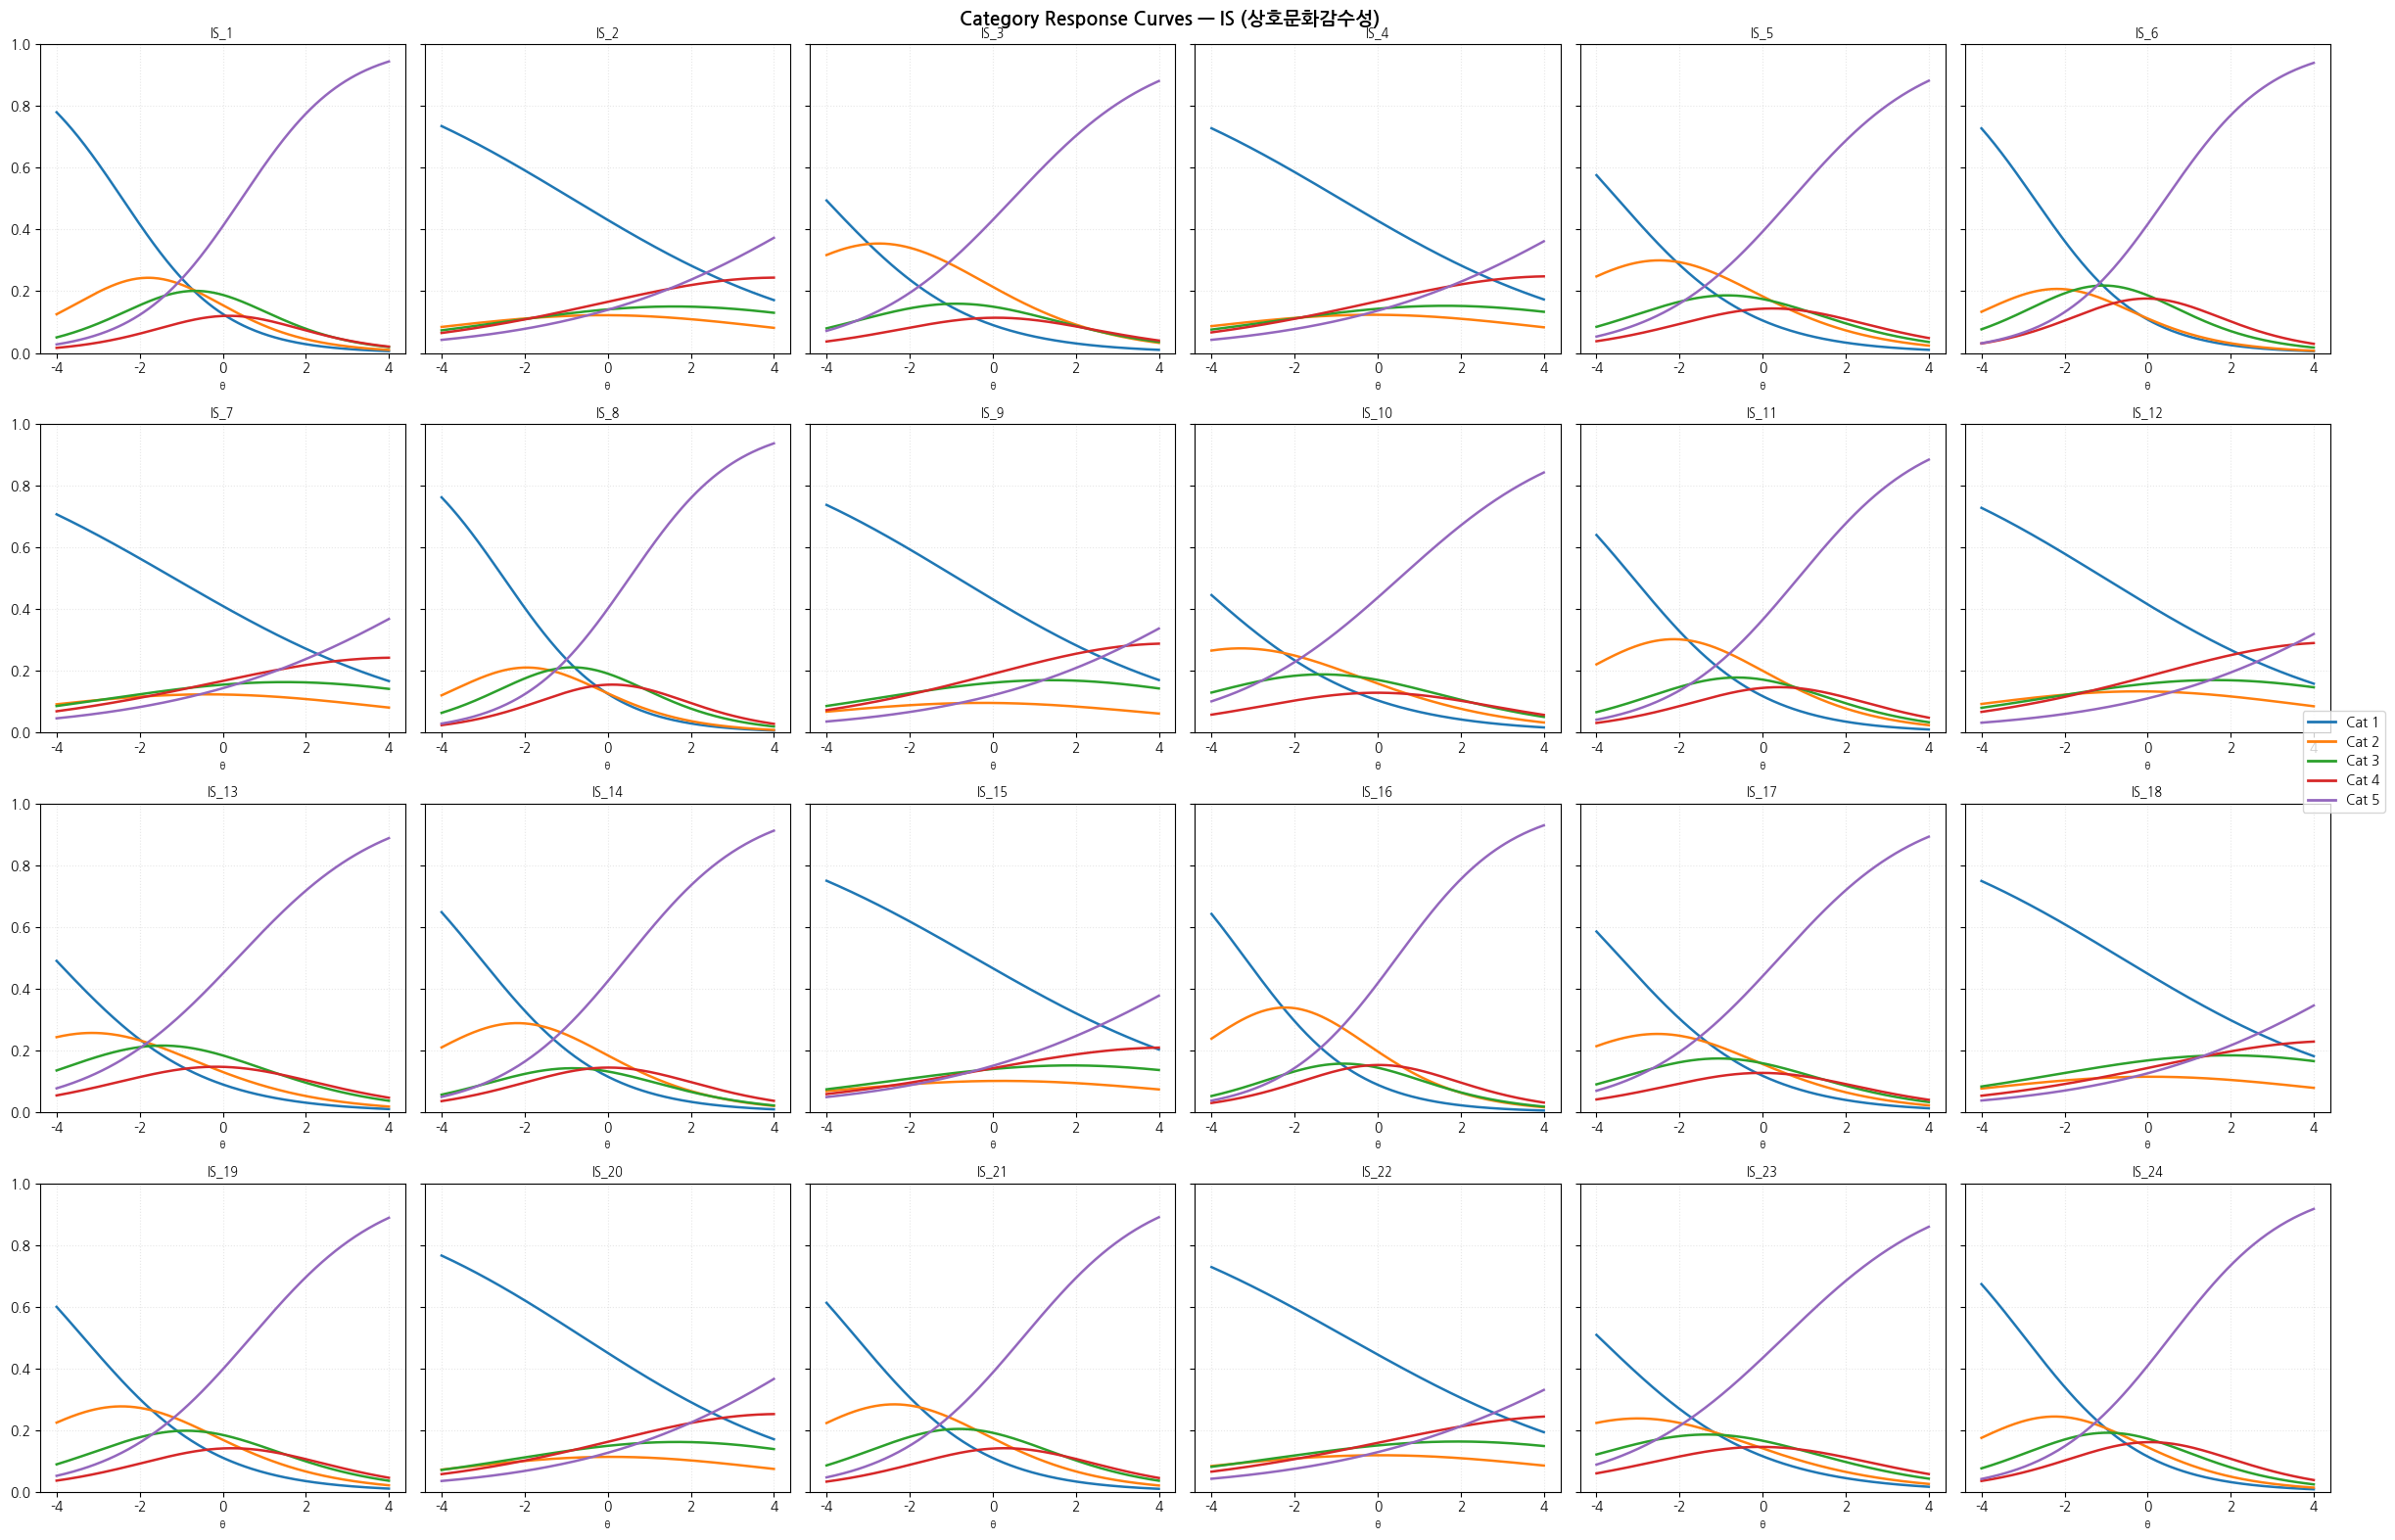

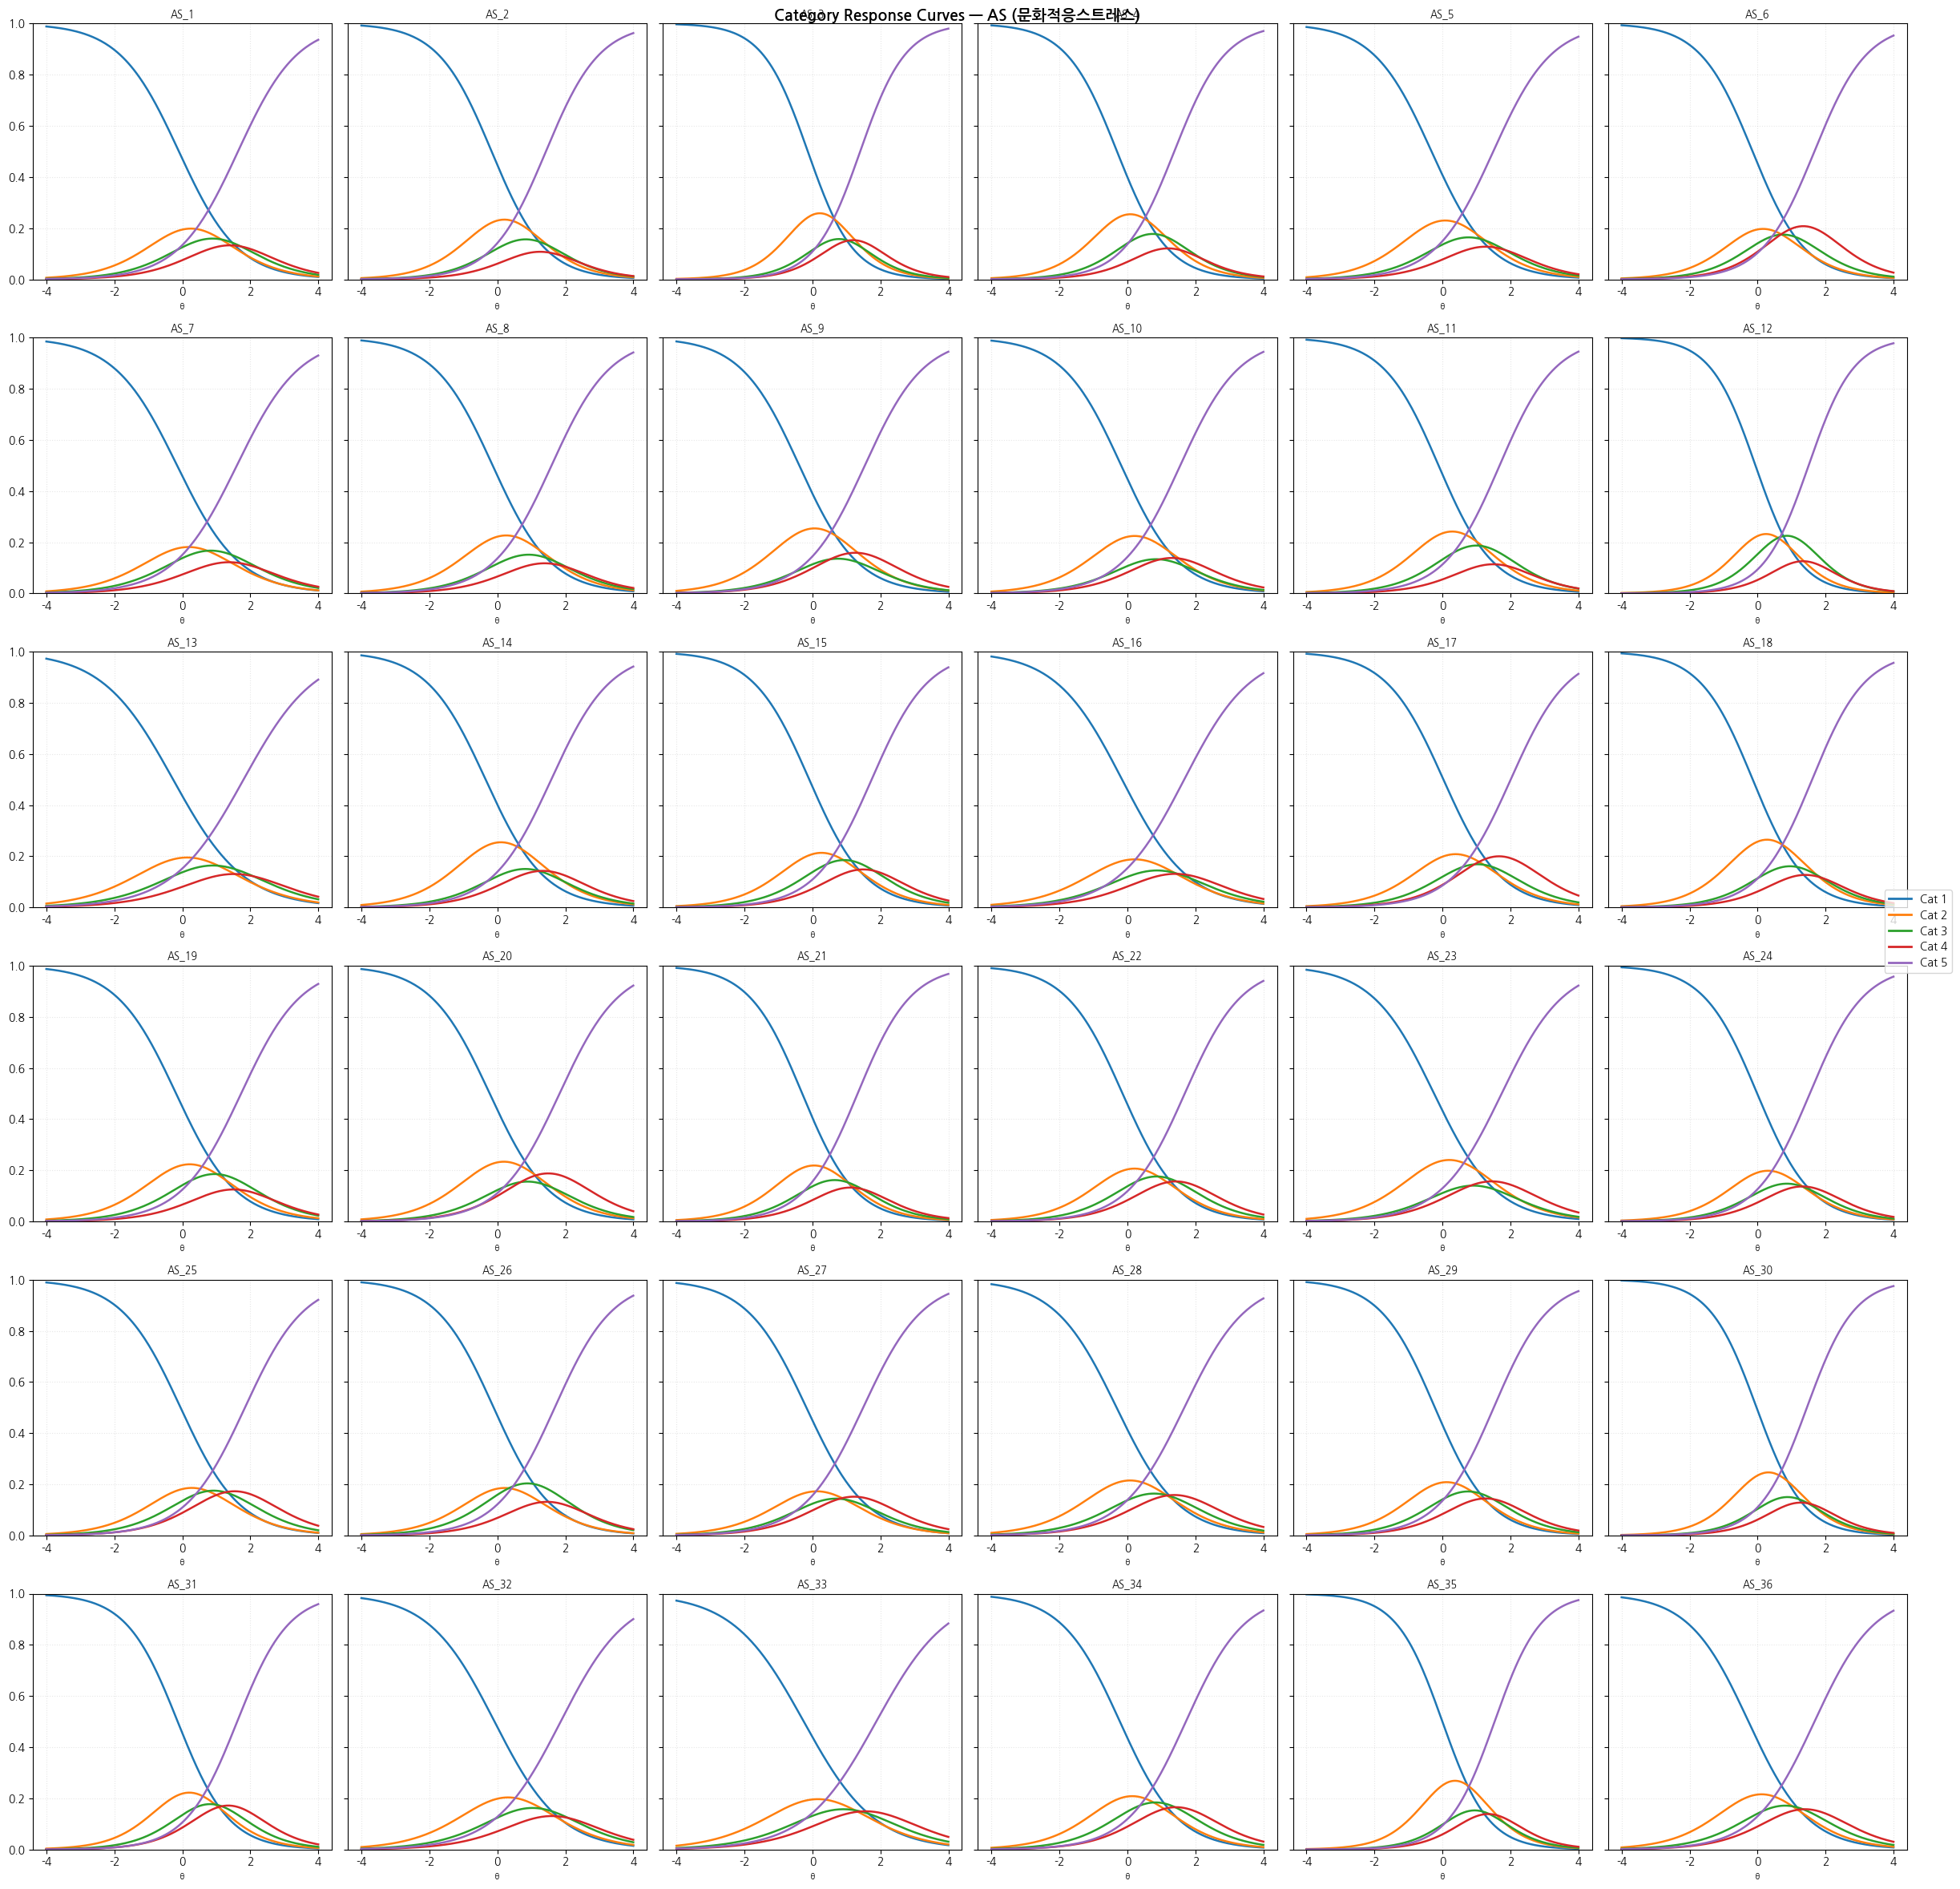

In [ ]:
# ══════════════════════════════════════════════════════════════
# [분석 6] CRC - 척도별 (중앙값 파라미터 사용)
# ══════════════════════════════════════════════════════════════

def compute_crc(a_i, b_i, theta_range):
    """
    GRM 범주반응곡선 계산
    a_i  : float - 변별도
    b_i  : array, shape (K-1,) - 능력치 척도 임계값
    theta_range : array - theta 격자
    
    Returns
    -------
    P : array, shape (len(theta_range), K)
    """
    K = len(b_i) + 1
    P = np.zeros((len(theta_range), K))
    for idx, t in enumerate(theta_range):
        # c_k = a * b_k (로짓 척도 cutpoint)
        c_vals = a_i * b_i
        eta = a_i * t
        P_ge = ([1.0] +
                [1.0 / (1.0 + np.exp(-(eta - c_vals[k])))
                 for k in range(K - 1)] +
                [0.0])
        for k in range(K):
            P[idx, k] = P_ge[k] - P_ge[k + 1]
    return P

theta_range = np.linspace(-4, 4, 200)

# SE용 색상 (4개 범주)
cat_colors_4 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
# IS/AS용 색상 (5개 범주)
cat_colors_5 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

def plot_crc_grid(a_arr, b_arr, item_names, scale_name,
                  nrow, ncol, figsize, K):
    """척도 내 모든 문항의 CRC를 격자 형태로 출력"""
    cat_colors = cat_colors_4 if K == 4 else cat_colors_5
    
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize, sharey=True)
    fig.suptitle(f'Category Response Curves — {scale_name} (K={K})',
                 fontsize=14, fontweight='bold')
    
    for ax, name, a_i, b_i in zip(
            axes.flatten(), item_names, a_arr, b_arr):
        P = compute_crc(a_i, b_i, theta_range)
        for k in range(K):
            ax.plot(theta_range, P[:, k],
                    color=cat_colors[k], linewidth=1.8)
        ax.set_title(name, fontsize=9)
        ax.set_xlabel('theta', fontsize=8)
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3, linestyle=':')
    
    # 빈 axes 숨기기
    for ax in axes.flatten()[len(item_names):]:
        ax.set_visible(False)
    
    # 공통 범례
    handles = [plt.Line2D([0], [0], color=cat_colors[k],
                          linewidth=2, label=f'Cat {k+1}')
               for k in range(K)]
    fig.legend(handles=handles,
               loc='center right', bbox_to_anchor=(1.02, 0.5),
               fontsize=10)
    plt.tight_layout()
    return fig

# SE CRC (10문항, 2x5, K=4)
fig_crc_se = plot_crc_grid(
    a_SE_med, b_SE_med, se_cols, 'SE (자아존중감)',
    nrow=2, ncol=5, figsize=(20, 8), K=4
)
plt.savefig("CRC_SE.png", dpi=150, bbox_inches='tight')
plt.show()

# IS CRC (24문항, 4x6, K=5)
fig_crc_is = plot_crc_grid(
    a_IS_med, b_IS_med, is_cols, 'IS (상호문화감수성)',
    nrow=4, ncol=6, figsize=(24, 16), K=5
)
plt.savefig("CRC_IS.png", dpi=150, bbox_inches='tight')
plt.show()

# AS CRC (36문항, 6x6, K=5)
fig_crc_as = plot_crc_grid(
    a_AS_med, b_AS_med, as_cols, 'AS (문화적응스트레스)',
    nrow=6, ncol=6, figsize=(24, 24), K=5
)
plt.savefig("CRC_AS.png", dpi=150, bbox_inches='tight')
plt.show()

Y_SE: (394, 10), Y_IS: (394, 24), Y_AS: (394, 36)
all_Y: (394, 70)

[범주 거리 분석]
가장 짧은 거리 문항: AS_30
  b값: [-0.029  0.672  1.093  1.453]
  d12=0.701, d23=0.421, d34=0.359
  총 거리: 1.481

가장 긴 거리 문항: SE_2
  b값: [-2.787 -1.104 -0.025  7.364]
  d12=1.682, d23=1.079, d34=7.389
  총 거리: 10.150

resp_min 범위: 0 ~ 4
resp_max 범위: 0 ~ 3


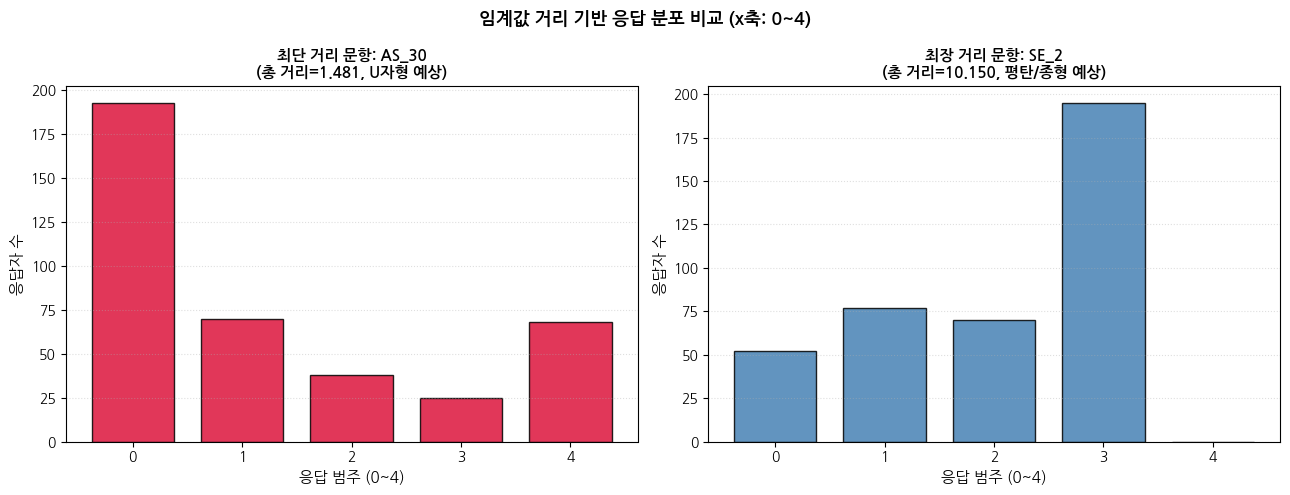

In [ ]:
# ── [분석 7] 히스토그램 수정: x축 0,1,2,3,4 표시 ──────────────
def draw_hist(ax, resp, K, title, color):
    """
    히스토그램 그리기
    resp: 0-indexed 응답값 (0 ~ K-1)
    x축: 0, 1, 2, ..., K-1 (요구사항: 0,1,2,3,4 네 가지 값 표시)
    y축: 응답자 수 (빈도)
    """
    # x축 범위를 항상 0~4로 고정 (요구사항 준수)
    x_max = 4  # 5점 척도 최대 = 4 (0-indexed)
    
    bins_edge = np.arange(-0.5, x_max + 1.5, 1)
    ax.hist(resp, bins=bins_edge, rwidth=0.75,
            color=color, alpha=0.85, edgecolor='black')
    
    # x축: 0,1,2,3,4 고정 표시
    ax.set_xticks([0, 1, 2, 3, 4])
    ax.set_xticklabels(['0', '1', '2', '3', '4'], fontsize=11)
    ax.set_xlim(-0.7, 4.7)
    
    ax.set_xlabel('응답 범주 (0, 1, 2, 3, 4)', fontsize=11)
    ax.set_ylabel('응답자 수', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.4, linestyle=':')
    
    # 각 막대 위에 빈도 표시
    for k in range(x_max + 1):
        count = np.sum(resp == k)
        if count > 0:
            ax.text(k, count + 1, str(count),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── 응답값 추출 (0-indexed: 원래 1~K → 0~K-1로 변환) ──────────
resp_min = all_Y[:, min_idx] - 1
resp_max = all_Y[:, max_idx] - 1

print(f"\nresp_min 범위: {resp_min.min()} ~ {resp_min.max()} (K={K_min})")
print(f"resp_max 범위: {resp_max.min()} ~ {resp_max.max()} (K={K_max})")

# ── 히스토그램 그리기 ─────────────────────────────────────────
fig_hist, axes_hist = plt.subplots(1, 2, figsize=(14, 6))

draw_hist(axes_hist[0], resp_min, K_min,
          f'최단 거리 문항: {all_names[min_idx]}\n'
          f'(K={K_min}, 총 거리={total_dist[min_idx]:.3f})\n'
          f'→ 양극단 쏠림(U자형) 예상',
          'crimson')

draw_hist(axes_hist[1], resp_max, K_max,
          f'최장 거리 문항: {all_names[max_idx]}\n'
          f'(K={K_max}, 총 거리={total_dist[max_idx]:.3f})\n'
          f'→ 분산된/종형 분포 예상',
          'steelblue')

fig_hist.suptitle('임계값 거리 기반 응답 분포 비교\n(x축: 0,1,2,3,4 | y축: 응답자 수)',
                  fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("histogram_distance_fixed.png", dpi=150, bbox_inches='tight')
plt.show()

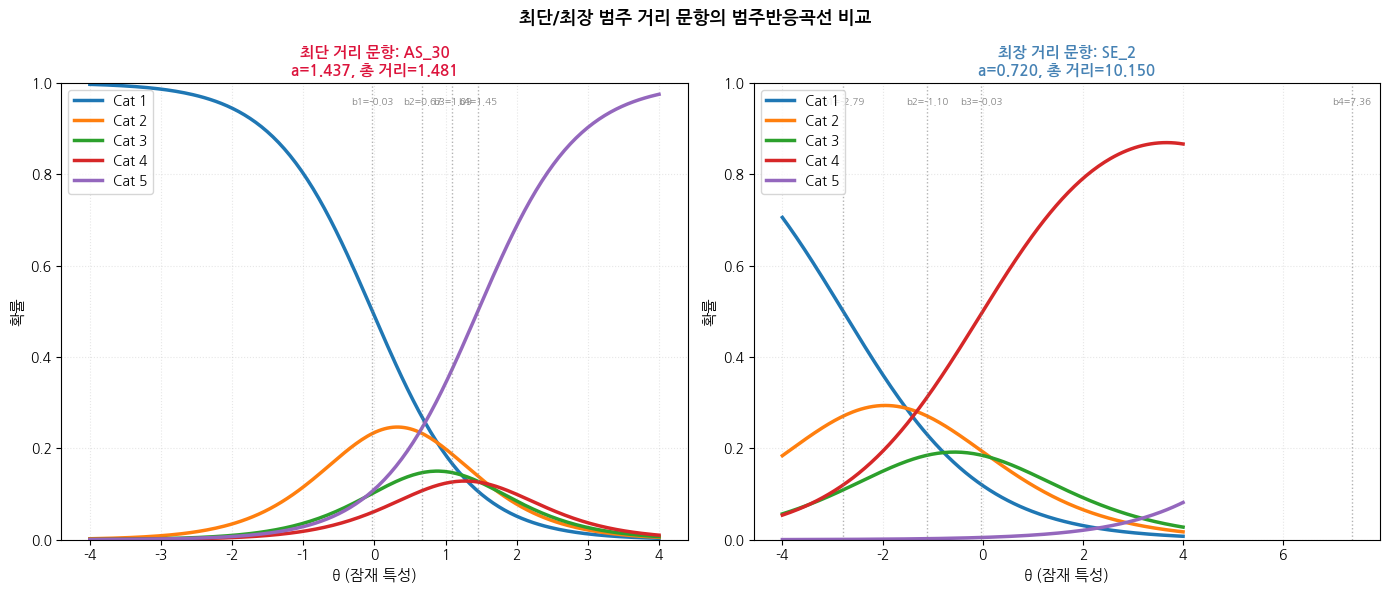

In [ ]:
# ══════════════════════════════════════════════════════════════
# [분석 8] 최단/최장 문항 CRC (단독 그래프)
# ══════════════════════════════════════════════════════════════

fig_crc_minmax, axes_mm = plt.subplots(1, 2, figsize=(14, 6))

for ax, idx, tag, color_title in [
        (axes_mm[0], min_idx, '최단 거리', 'crimson'),
        (axes_mm[1], max_idx, '최장 거리', 'steelblue')]:
    
    b_i = all_b_list[idx]
    a_i = all_a[idx]
    K_i = item_K[idx]
    cat_colors = cat_colors_4 if K_i == 4 else cat_colors_5
    
    P = compute_crc(a_i, b_i, theta_range)
    for k in range(K_i):
        ax.plot(theta_range, P[:, k],
                color=cat_colors[k], linewidth=2.5,
                label=f'Cat {k+1}')
    
    ax.set_xlabel('theta (잠재 특성)', fontsize=11)
    ax.set_ylabel('확률', fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_title(
        f'{tag} 문항: {all_names[idx]} (K={K_i})\n'
        f'a={a_i:.3f}, 총 거리={total_dist[idx]:.3f}',
        fontsize=11, fontweight='bold', color=color_title)
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(alpha=0.3, linestyle=':')
    
    # 임계값 수직선 표시
    for k, bval in enumerate(b_i):
        ax.axvline(bval, color='gray', linestyle=':', alpha=0.6, linewidth=1)
        ax.text(bval, 0.97, f'b{k+1}={bval:.2f}',
                ha='center', va='top', fontsize=7, color='gray')

fig_crc_minmax.suptitle('최단/최장 범주 거리 문항의 범주반응곡선 비교',
                        fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("CRC_minmax_distance.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════
# [최종 요약] 상관관계 테이블 출력
# ══════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("  3차원 GRM 분석 결과 요약")
print("="*60)

print("\n[원본 데이터 (N=394) theta 상관관계]")
pairs = [('SE', 'IS', 0, 1), ('SE', 'AS', 0, 2), ('IS', 'AS', 1, 2)]
theta_orig_mat = np.column_stack([theta_SE_med, theta_IS_med, theta_AS_med])

for n1, n2, i, j in pairs:
    r, p = pearsonr(theta_orig_mat[:, i], theta_orig_mat[:, j])
    star = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    direction = "정적 상관 ↑" if r > 0 else "부적 상관 ↓"
    print(f"  {n1} vs {n2}: r = {r:+.3f} ({star}) → {direction}")

print(f"\n[원 논문 CTT 상관관계 (비교 기준)]")
print(f"  SE vs IS: r = +0.46 (***)")
print(f"  SE vs AS: r = -0.41 (***)")
print(f"  IS vs AS: r = -0.49 (***)")

print(f"\n[해석]")
print(f"  • IRT 기반 theta 상관이 CTT 상관과 방향이 일치하면 모형 타당도 지지")
print(f"  • 시뮬레이션 데이터이므로 실제 원 논문과 수치 차이는 정상")
print(f"  • 대표본 시뮬레이션에서 상관이 더 안정적으로 추정됨")
print("="*60)


  3차원 GRM 분석 결과 요약

[원본 데이터 (N=394) theta 상관관계]
  SE vs IS: r = +0.107 (*) → 정적 상관 ↑
  SE vs AS: r = -0.116 (*) → 부적 상관 ↓
  IS vs AS: r = -0.358 (***) → 부적 상관 ↓

[원 논문 CTT 상관관계 (비교 기준)]
  SE vs IS: r = +0.46 (***)
  SE vs AS: r = -0.41 (***)
  IS vs AS: r = -0.49 (***)

[해석]
  • IRT 기반 theta 상관이 CTT 상관과 방향이 일치하면 모형 타당도 지지
  • 시뮬레이션 데이터이므로 실제 원 논문과 수치 차이는 정상
  • 대표본 시뮬레이션에서 상관이 더 안정적으로 추정됨


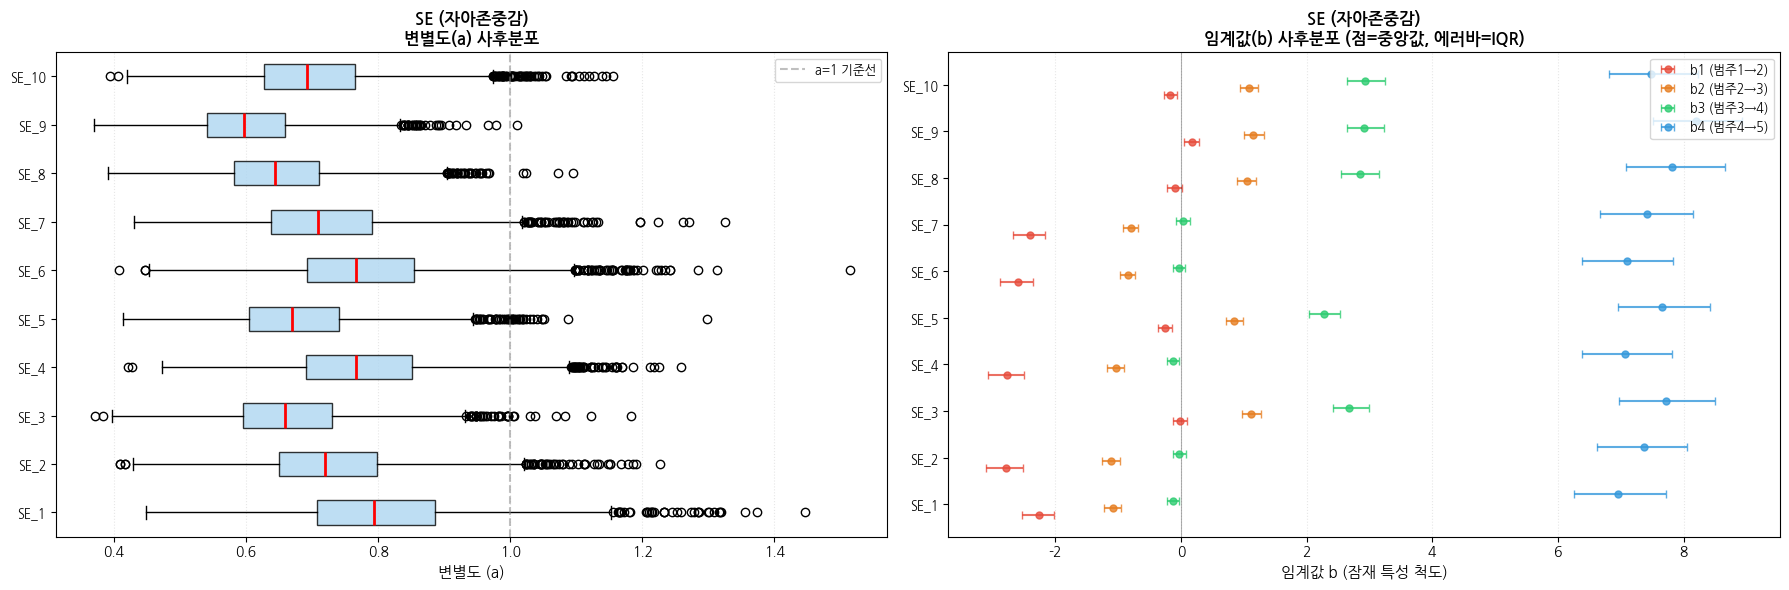

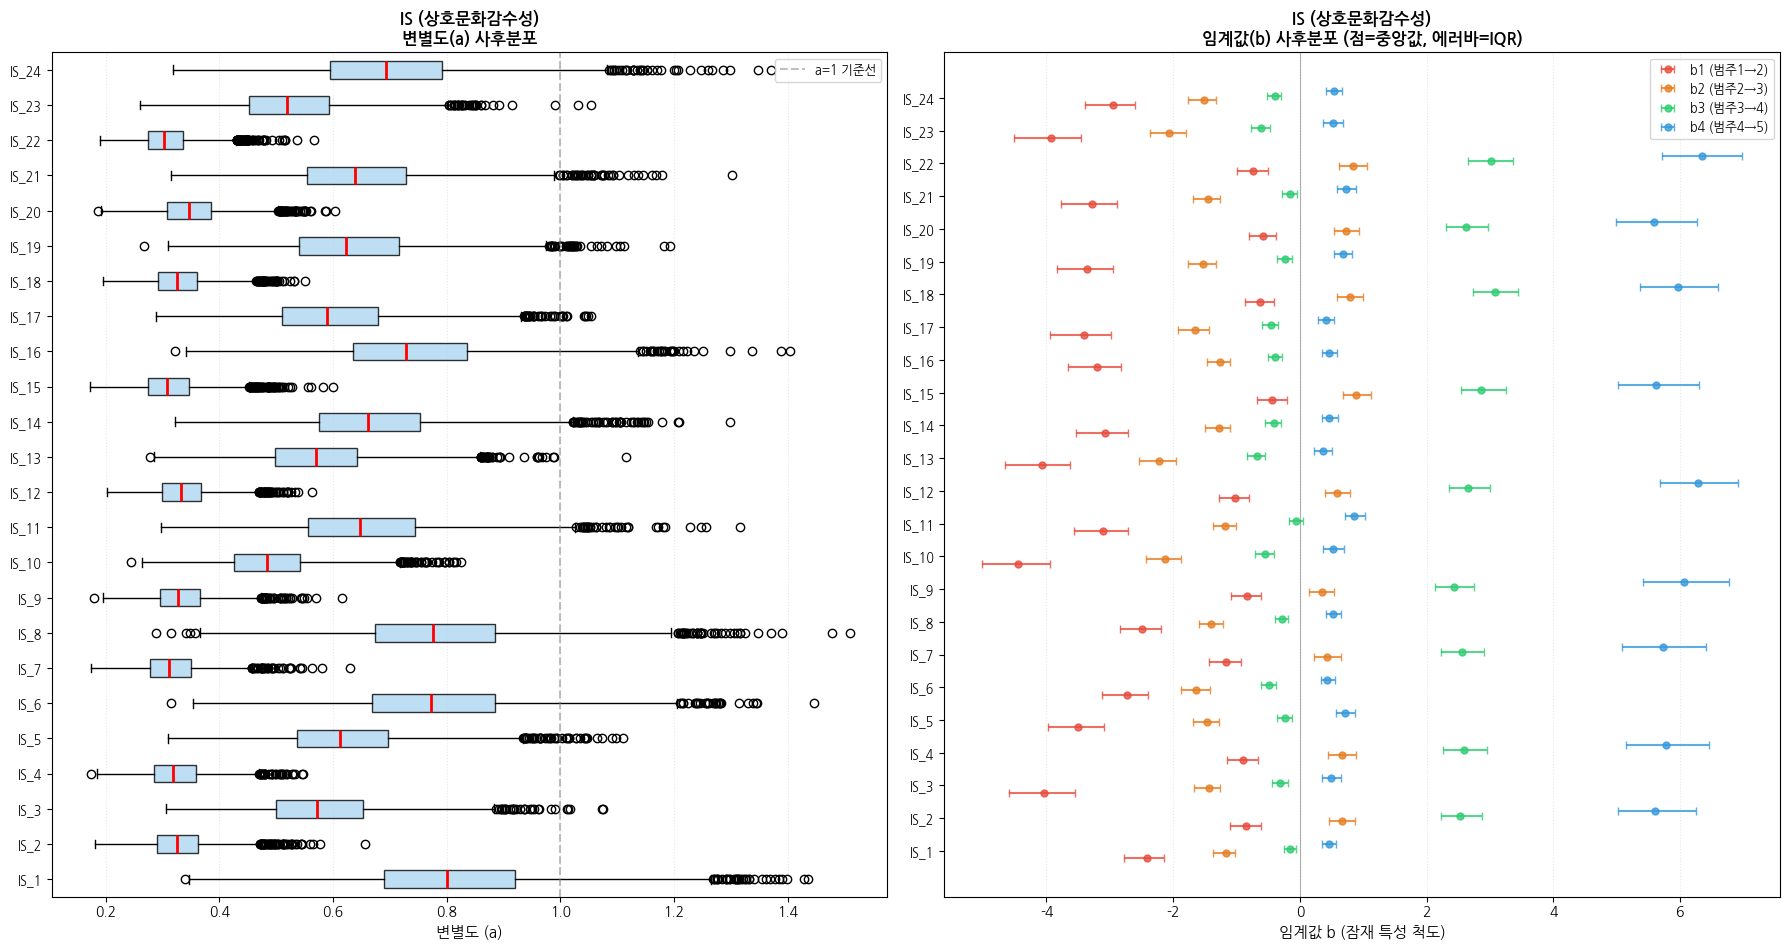

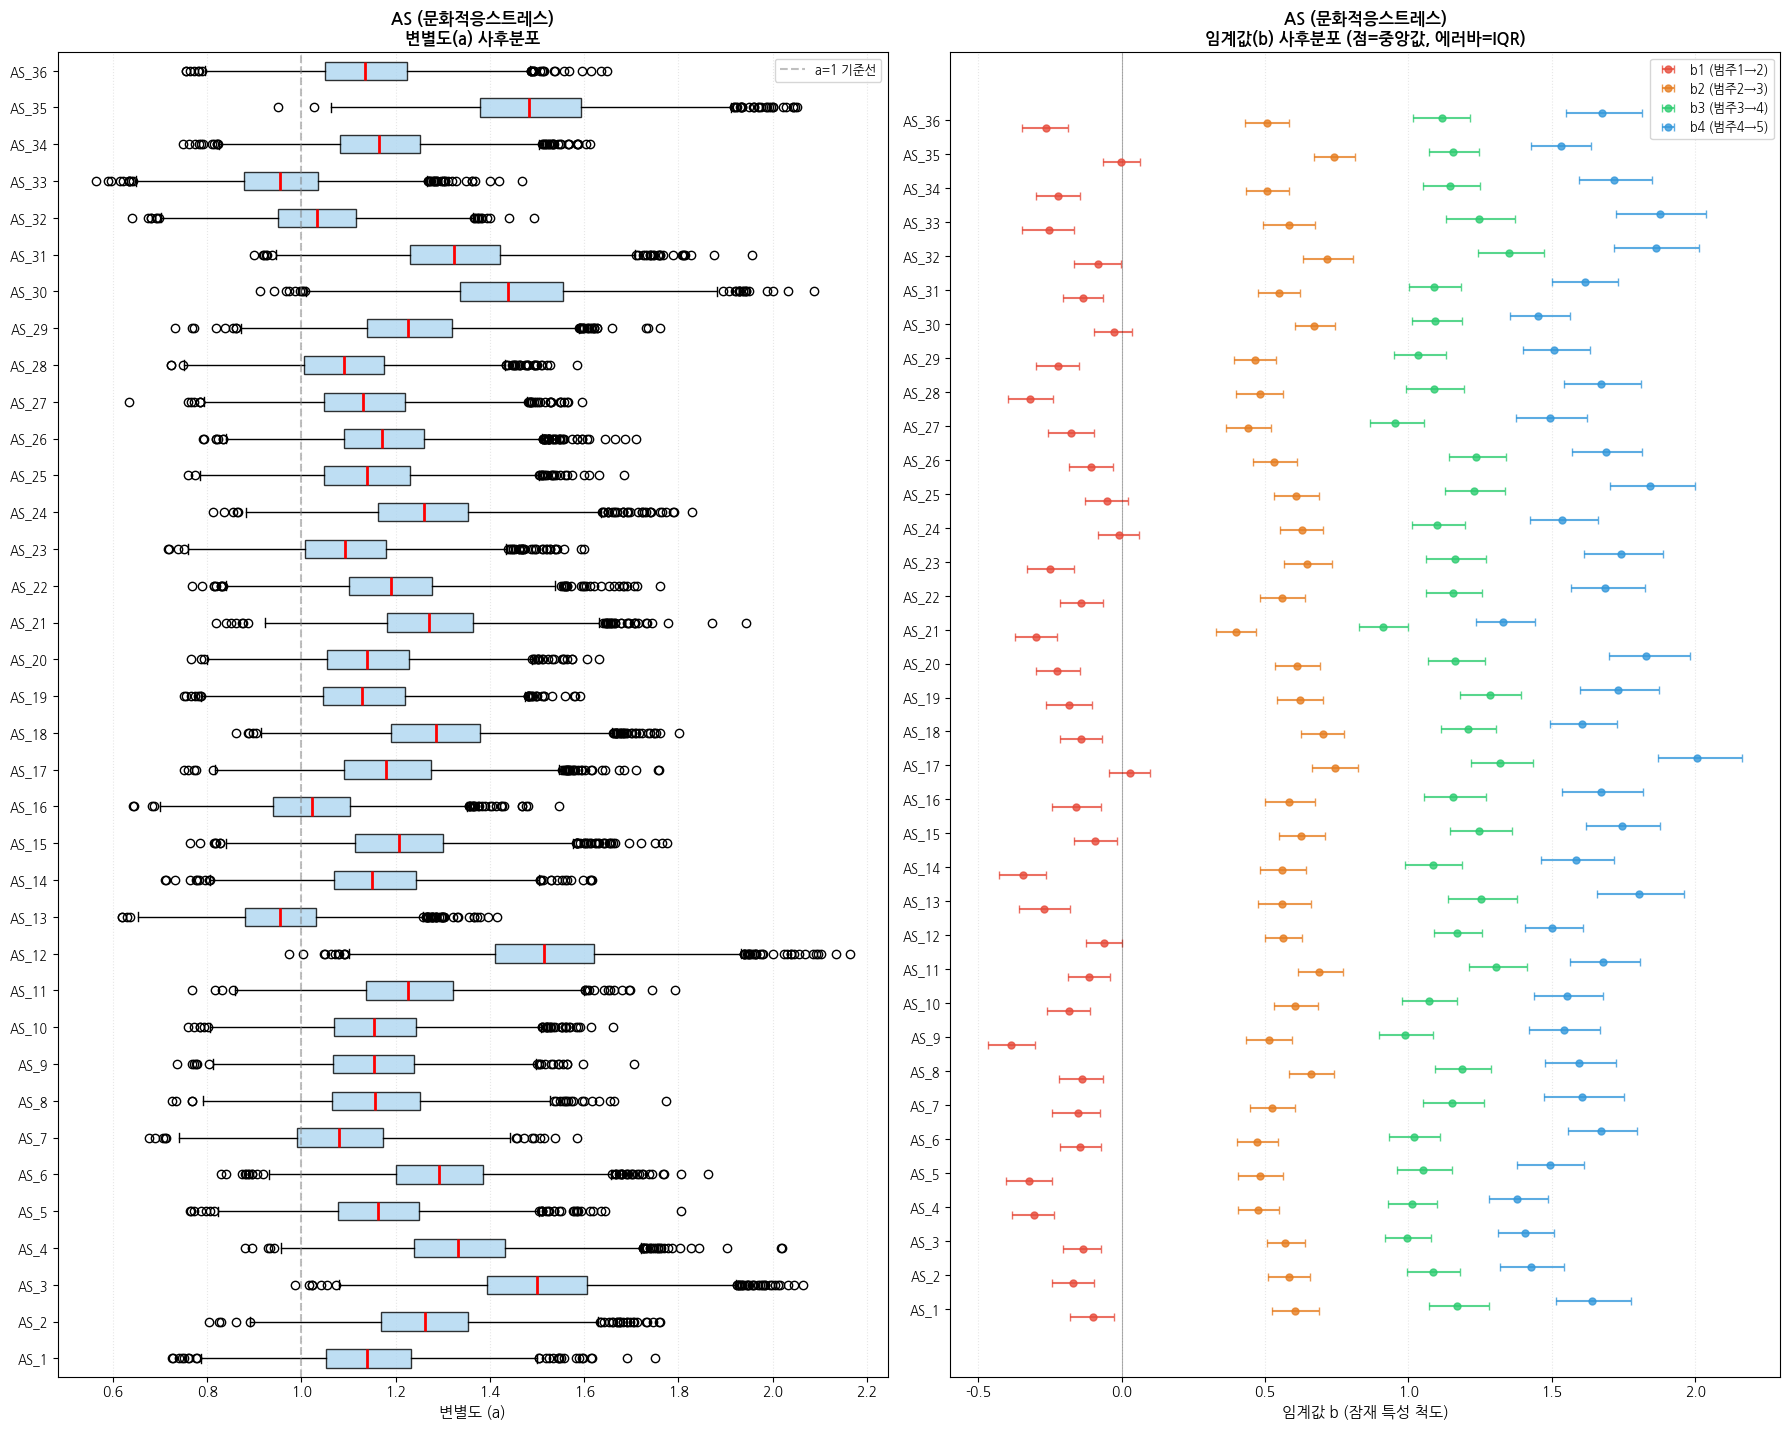

In [ ]:
# ══════════════════════════════════════════════════════════════
# [추가] 모수 사후분포 시각화: 변별도 및 임계값 박스플롯
# ══════════════════════════════════════════════════════════════

def plot_parameter_posterior(fit, scale_name, n_items, item_cols,
                             param_a='a_SE', param_b='b_SE', n_cutpoints=3):
    """
    변별도(a)와 임계값(b) 사후분포를 박스플롯으로 시각화
    
    n_cutpoints : int - 임계값 개수 (SE=3, IS/AS=4)
    """
    a_samples = fit.stan_variable(param_a)  # (4000, n_items)
    b_samples = fit.stan_variable(param_b)  # (4000, n_items, n_cutpoints)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, max(6, n_items * 0.4)))
    
    # ── [왼쪽] 변별도(a) 박스플롯 ────────────────────────────
    ax_a = axes[0]
    a_data = [a_samples[:, i] for i in range(n_items)]
    
    bp_a = ax_a.boxplot(
        a_data,
        vert=False,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(color='red', linewidth=2)
    )
    
    for patch in bp_a['boxes']:
        patch.set_facecolor('#AED6F1')
        patch.set_alpha(0.8)
    
    ax_a.set_yticks(range(1, n_items + 1))
    ax_a.set_yticklabels(item_cols, fontsize=9)
    ax_a.set_xlabel('변별도 (a)', fontsize=11)
    ax_a.set_title(f'{scale_name}\n변별도(a) 사후분포',
                   fontsize=12, fontweight='bold')
    ax_a.axvline(1.0, color='gray', linestyle='--', alpha=0.5, label='a=1 기준선')
    ax_a.grid(axis='x', alpha=0.3, linestyle=':')
    ax_a.legend(fontsize=9)
    
    # ── [오른쪽] 임계값(b) 박스플롯 ──────────────────────────
    ax_b = axes[1]
    
    # 임계값 색상 (n_cutpoints에 맞게)
    threshold_colors_3 = ['#E74C3C', '#2ECC71', '#3498DB']
    threshold_colors_4 = ['#E74C3C', '#E67E22', '#2ECC71', '#3498DB']
    threshold_colors = threshold_colors_3 if n_cutpoints == 3 else threshold_colors_4
    threshold_labels = [f'b{k+1} (범주{k+1}->{k+2})' for k in range(n_cutpoints)]
    
    for k in range(n_cutpoints):
        b_k_med = np.median(b_samples[:, :, k], axis=0)
        b_k_q25 = np.percentile(b_samples[:, :, k], 25, axis=0)
        b_k_q75 = np.percentile(b_samples[:, :, k], 75, axis=0)
        
        y_positions = np.arange(n_items) + k * 0.15
        
        ax_b.errorbar(
            x=b_k_med,
            y=y_positions,
            xerr=[b_k_med - b_k_q25, b_k_q75 - b_k_med],
            fmt='o',
            color=threshold_colors[k],
            markersize=5,
            capsize=3,
            linewidth=1.5,
            label=threshold_labels[k],
            alpha=0.8
        )
    
    n_cp_offset = (n_cutpoints - 1) * 0.15 / 2
    ax_b.set_yticks(np.arange(n_items) + n_cp_offset)
    ax_b.set_yticklabels(item_cols, fontsize=9)
    ax_b.set_xlabel('임계값 b (잠재 특성 척도)', fontsize=11)
    ax_b.set_title(f'{scale_name}\n임계값(b) 사후분포 (점=중앙값, 에러바=IQR)',
                   fontsize=12, fontweight='bold')
    ax_b.axvline(0, color='black', linestyle='-', alpha=0.3, linewidth=0.8)
    ax_b.grid(axis='x', alpha=0.3, linestyle=':')
    ax_b.legend(fontsize=9, loc='upper right')
    
    plt.tight_layout()
    return fig

# ── SE 척도: K=4 → 3개 임계값 ────────────────────────────────
fig_param_se = plot_parameter_posterior(
    fit_md, 'SE (자아존중감, 4점 척도)', I_SE, se_cols,
    param_a='a_SE', param_b='b_SE', n_cutpoints=3
)
plt.savefig("param_posterior_SE.png", dpi=150, bbox_inches='tight')
plt.show()

# ── IS 척도: K=5 → 4개 임계값 ────────────────────────────────
fig_param_is = plot_parameter_posterior(
    fit_md, 'IS (상호문화감수성, 5점 척도)', I_IS, is_cols,
    param_a='a_IS', param_b='b_IS', n_cutpoints=4
)
plt.savefig("param_posterior_IS.png", dpi=150, bbox_inches='tight')
plt.show()

# ── AS 척도: K=5 → 4개 임계값 ────────────────────────────────
fig_param_as = plot_parameter_posterior(
    fit_md, 'AS (문화적응스트레스, 5점 척도)', I_AS, as_cols,
    param_a='a_AS', param_b='b_AS', n_cutpoints=4
)
plt.savefig("param_posterior_AS.png", dpi=150, bbox_inches='tight')
plt.show()